In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


# Distribution of Δ log P Values for Negative and Positive Weights

In [2]:
files = sorted(glob.glob("AB_full_mutation_table*.csv"))

dfs = []
for f in files:
    df = pd.read_csv(f)
    df["source_file"] = f
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)
all_df["delta_logp_flipped"] = -1 * all_df["delta_logp"]

<Figure size 1000x500 with 0 Axes>

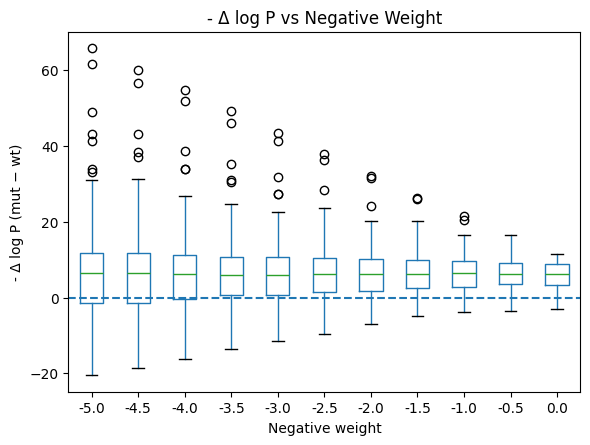

In [3]:
plt.figure(figsize=(10,5))
all_df.boxplot(
    column="delta_logp_flipped",
    by="neg_weight",
    grid=False
)

plt.axhline(0, linestyle="--")
plt.xlabel("Negative weight")
plt.ylabel("- Δ log P (mut − wt)")
plt.title("- Δ log P vs Negative Weight")
plt.suptitle("") 
plt.show()


In [4]:
resi = df[df["pdb_resi"] == 22]

logps = np.concatenate([
    resi["logp_A_mut"].values,
    resi["logp_A_wt"].values[:1]   # WT
])

np.sum(np.exp(logps))


np.float64(0.9960789709645643)

In [5]:
resi = df[df["pdb_resi"] == 22]

logps = np.concatenate([
    resi["logp_B_mut"].values,
    resi["logp_B_wt"].values[:1]   # WT
])

np.sum(np.exp(logps))


np.float64(0.9950252008046254)

In [6]:
resi = df[df["pdb_resi"] == 22]

logps = np.concatenate([
    resi["logp_E_mut"].values,
    resi["logp_E_wt"].values[:1]   # WT
])

np.sum(np.exp(logps))


np.float64(0.995522818766341)

In [7]:
resi = df[df["pdb_resi"] == 22]

logps = np.concatenate([
    resi["logp_F_mut"].values,
    resi["logp_F_wt"].values[:1]   # WT
])

np.sum(np.exp(logps))


np.float64(0.9960699047732222)

['posAB_full_mutation_table0.2.csv', 'posAB_full_mutation_table0.4.csv', 'posAB_full_mutation_table0.6.csv', 'posAB_full_mutation_table0.8.csv', 'posAB_full_mutation_table1.0.csv']


<Figure size 1000x500 with 0 Axes>

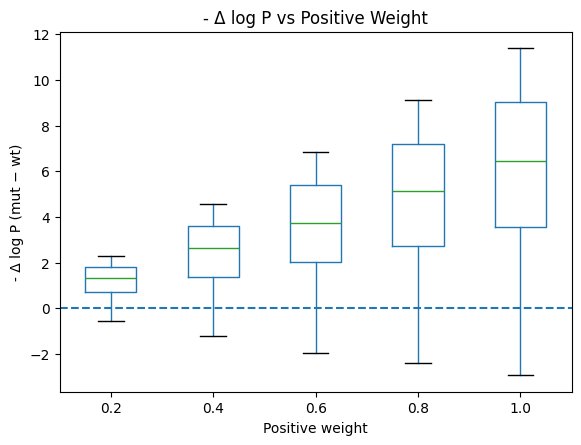

In [8]:
files = sorted(glob.glob("posAB_full_mutation_table*.csv"))
print(files)
dfs = []
for f in files:
    df = pd.read_csv(f)
    df["source_file"] = f
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

all_df["delta_logp_flipped"] = -1 * all_df["delta_logp"]

plt.figure(figsize=(10,5))
all_df.boxplot(
    column="delta_logp_flipped",
    by="pos_weight",
    grid=False
)

plt.axhline(0, linestyle="--")
plt.xlabel("Positive weight")
plt.ylabel("- Δ log P (mut − wt)")
plt.title("- Δ log P vs Positive Weight")
plt.suptitle("")
plt.show()


# Delta logp Mutation Scans for Each Residue (Negative Weights)

In [9]:
files = sorted(glob.glob("AB_full_mutation_table*.csv"))
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

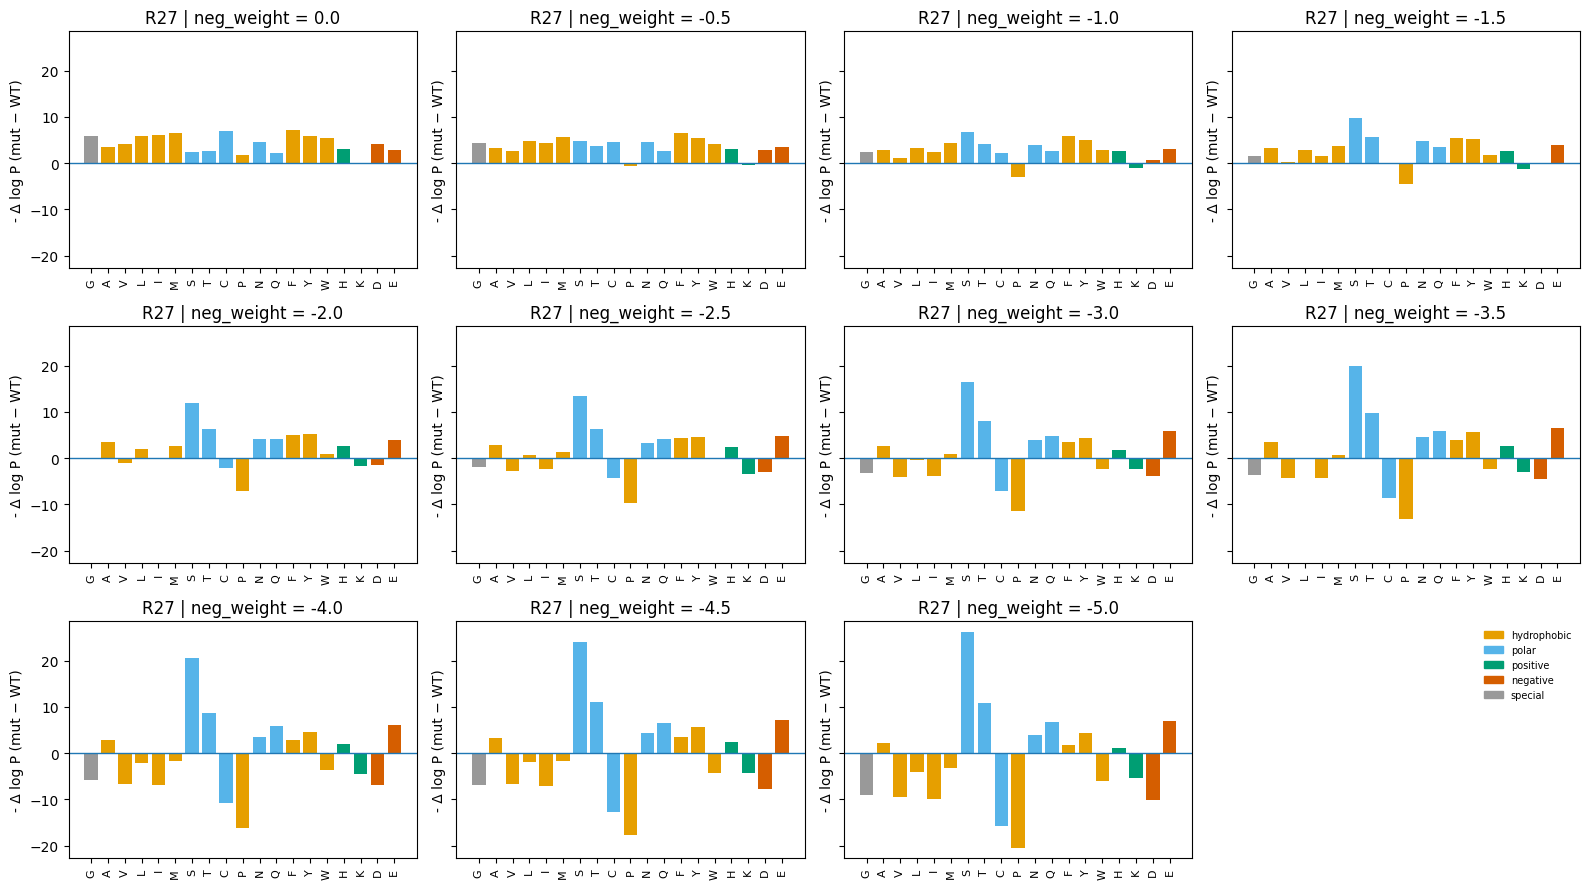

In [10]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# User parameters
# ----------------------------
pattern = "AB_full_mutation_table*.csv"
target_chain = "A"
target_pos = 22
ncols = 4
pdb_offset = 5  # for display only


# ----------------------------
# Load data
# ----------------------------
files = sorted(glob.glob(pattern))
if not files:
    raise FileNotFoundError(f"No files match pattern: {pattern}")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["neg_weight"] = pd.to_numeric(df["neg_weight"], errors="coerce")
df["pdb_resi"] = df["pdb_resi"].astype(int)

# ----------------------------
# Filter to target residue
# ----------------------------
df = df[
    (df["chain"] == target_chain) &
    (df["pdb_resi"] == target_pos)
].copy()

if df.empty:
    raise ValueError(f"No rows found for {target_chain}{target_pos}")

wt_aa = df["wt"].iloc[0]

# ----------------------------
# Use Δ log P already in CSV
# ----------------------------


plot_df = df[["neg_weight", "mut", "delta_logp"]].copy()

plot_df = plot_df[plot_df["mut"] != "WT"]

# Remove self-mutation (e.g., mut == "R" for R27)
plot_df = plot_df[plot_df["mut"] != wt_aa]
plot_df["delta_logp"] *= -1

aa_property = {
    # hydrophobic
    "A":"hydrophobic","V":"hydrophobic","L":"hydrophobic","I":"hydrophobic","M":"hydrophobic","F":"hydrophobic","W":"hydrophobic","Y":"hydrophobic","P":"hydrophobic",

    # polar
    "S":"polar","T":"polar","N":"polar","Q":"polar","C":"polar",

    # charged positive
    "K":"positive","R":"positive","H":"positive",

    # charged negative
    "D":"negative","E":"negative",

    # special
    "G":"special",
}

prop_colors = {
    "hydrophobic": "#E69F00",   # orange
    "polar": "#56B4E9",         # blue
    "positive": "#009E73",      # green
    "negative": "#D55E00",      # red
    "special": "#999999"        # gray
}

plot_df["property"] = plot_df["mut"].map(aa_property)
plot_df["color"] = plot_df["property"].map(prop_colors)


aa_order = [
    "WT", "G", "A", "V", "L", "I", "M",
    "S", "T", "C", "P", "N", "Q",
    "F", "Y", "W",
    "H", "K", "R",
    "D", "E"
]

plot_df["mut"] = pd.Categorical(
    plot_df["mut"],
    categories=aa_order,
    ordered=True
)



# ----------------------------
# Faceted bar plot by neg_weight
# ----------------------------
weights = (
    plot_df["neg_weight"]
    .dropna()
    .astype(float)
    .sort_values(ascending=False)  # ← reverse order
    .unique()
)


nrows = int(np.ceil(len(weights) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4 * ncols, 3 * nrows),
    sharey=True
)
axes = axes.flatten()

for ax, w in zip(axes, weights):
    sub = (
    plot_df[plot_df["neg_weight"] == w]
    .sort_values("mut")
    )

    if sub.empty:
        ax.axis("off")
        continue

    x = np.arange(len(sub))

    ax.bar(x, sub["delta_logp"], color=sub["color"])



    display_pos = target_pos + pdb_offset
    ax.set_title(f"{wt_aa}{display_pos} | neg_weight = {w}")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["mut"], rotation=90, fontsize=8)



    ax.axhline(0, linewidth=1)
    ax.set_ylabel("- Δ log P (mut − WT)")

# Turn off unused axes
for ax in axes[len(weights):]:
    ax.axis("off")

legend_handles = [
    Patch(color=c, label=p) for p, c in prop_colors.items()
]

ax.legend(
    handles=legend_handles,
    fontsize=7,
    frameon=False,
    loc="upper right"
)


fig.tight_layout()
plt.show()


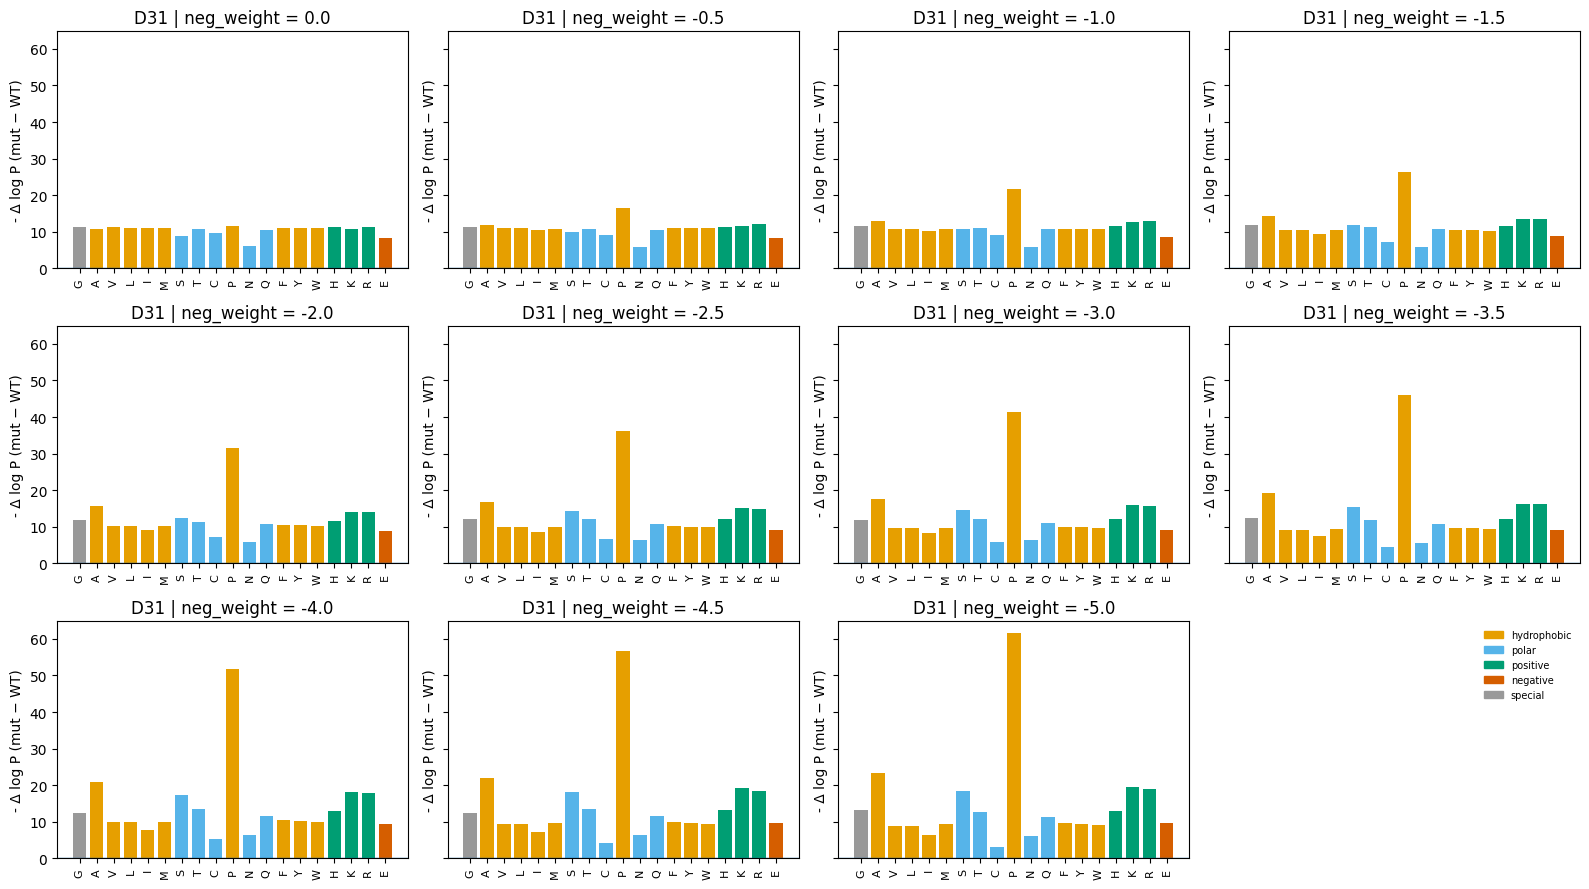

In [11]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# User parameters
# ----------------------------
pattern = "AB_full_mutation_table*.csv"
target_chain = "A"
target_pos = 26
ncols = 4
pdb_offset = 5  # for display only


# ----------------------------
# Load data
# ----------------------------
files = sorted(glob.glob(pattern))
if not files:
    raise FileNotFoundError(f"No files match pattern: {pattern}")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["neg_weight"] = pd.to_numeric(df["neg_weight"], errors="coerce")
df["pdb_resi"] = df["pdb_resi"].astype(int)

# ----------------------------
# Filter to target residue
# ----------------------------
df = df[
    (df["chain"] == target_chain) &
    (df["pdb_resi"] == target_pos)
].copy()

if df.empty:
    raise ValueError(f"No rows found for {target_chain}{target_pos}")

wt_aa = df["wt"].iloc[0]

# ----------------------------
# Use Δ log P already in CSV
# ----------------------------


plot_df = df[["neg_weight", "mut", "delta_logp"]].copy()

plot_df = plot_df[plot_df["mut"] != "WT"]

# Remove self-mutation (e.g., mut == "R" for R27)
plot_df = plot_df[plot_df["mut"] != wt_aa]
plot_df["delta_logp"] *= -1

aa_property = {
    # hydrophobic
    "A":"hydrophobic","V":"hydrophobic","L":"hydrophobic","I":"hydrophobic","M":"hydrophobic","F":"hydrophobic","W":"hydrophobic","Y":"hydrophobic","P":"hydrophobic",

    # polar
    "S":"polar","T":"polar","N":"polar","Q":"polar","C":"polar",

    # charged positive
    "K":"positive","R":"positive","H":"positive",

    # charged negative
    "D":"negative","E":"negative",

    # special
    "G":"special",
}

prop_colors = {
    "hydrophobic": "#E69F00",   # orange
    "polar": "#56B4E9",         # blue
    "positive": "#009E73",      # green
    "negative": "#D55E00",      # red
    "special": "#999999"        # gray
}

plot_df["property"] = plot_df["mut"].map(aa_property)
plot_df["color"] = plot_df["property"].map(prop_colors)


aa_order = [
    "WT", "G", "A", "V", "L", "I", "M",
    "S", "T", "C", "P", "N", "Q",
    "F", "Y", "W",
    "H", "K", "R",
    "D", "E"
]

plot_df["mut"] = pd.Categorical(
    plot_df["mut"],
    categories=aa_order,
    ordered=True
)



# ----------------------------
# Faceted bar plot by neg_weight
# ----------------------------
weights = (
    plot_df["neg_weight"]
    .dropna()
    .astype(float)
    .sort_values(ascending=False)  # ← reverse order
    .unique()
)


nrows = int(np.ceil(len(weights) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4 * ncols, 3 * nrows),
    sharey=True
)
axes = axes.flatten()

for ax, w in zip(axes, weights):
    sub = (
    plot_df[plot_df["neg_weight"] == w]
    .sort_values("mut")
    )

    if sub.empty:
        ax.axis("off")
        continue

    x = np.arange(len(sub))

    ax.bar(x, sub["delta_logp"], color=sub["color"])



    display_pos = target_pos + pdb_offset
    ax.set_title(f"{wt_aa}{display_pos} | neg_weight = {w}")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["mut"], rotation=90, fontsize=8)



    ax.axhline(0, linewidth=1)
    ax.set_ylabel("- Δ log P (mut − WT)")

# Turn off unused axes
for ax in axes[len(weights):]:
    ax.axis("off")

legend_handles = [
    Patch(color=c, label=p) for p, c in prop_colors.items()
]

ax.legend(
    handles=legend_handles,
    fontsize=7,
    frameon=False,
    loc="upper right"
)


fig.tight_layout()
plt.show()


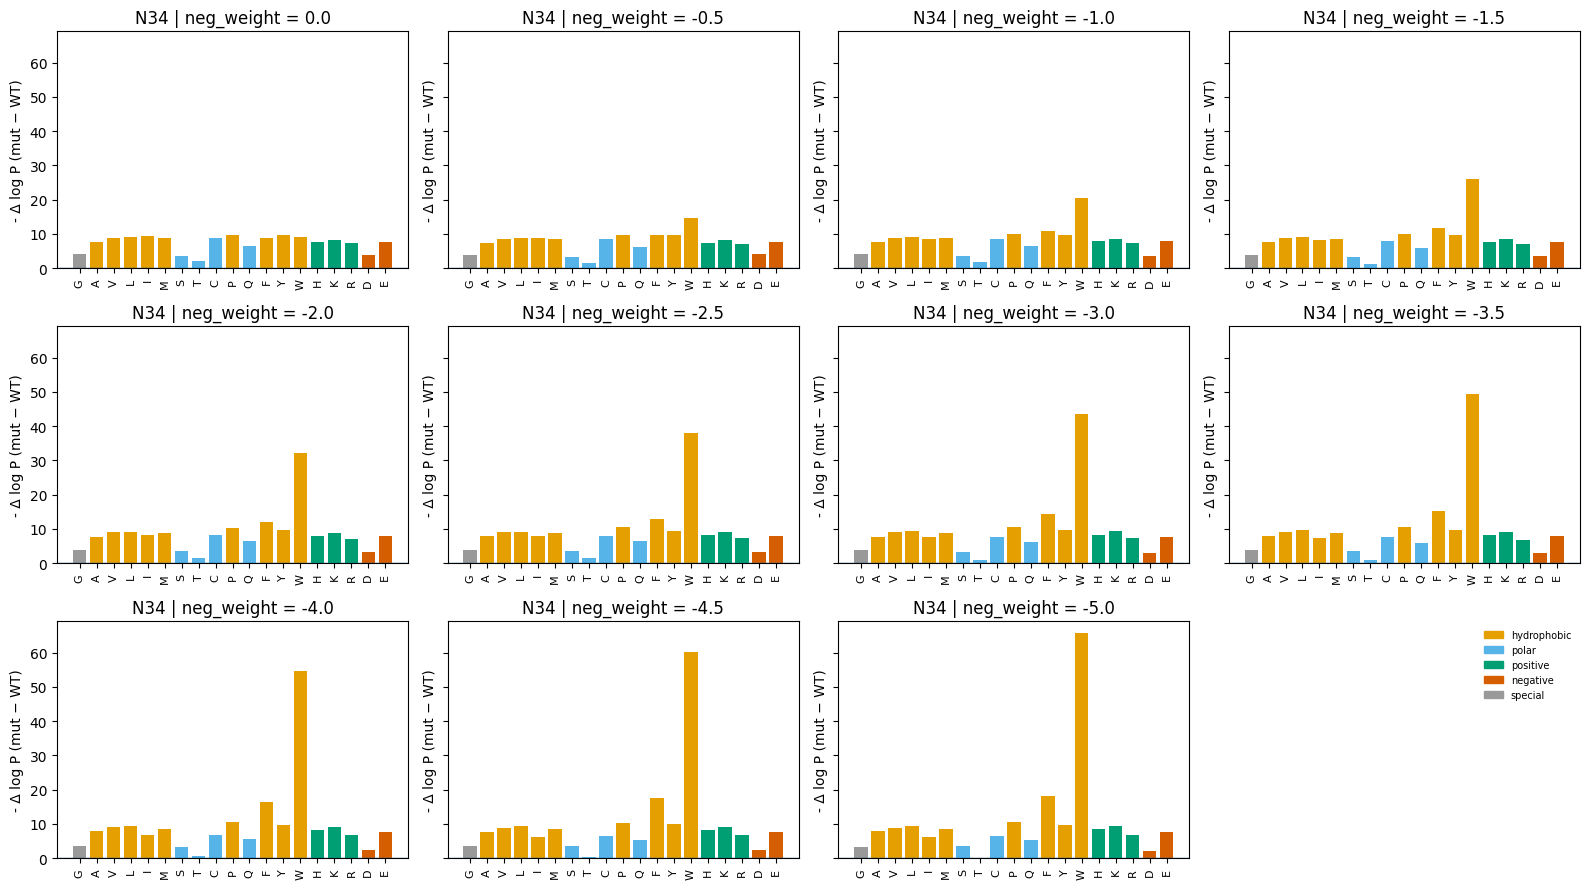

In [12]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# User parameters
# ----------------------------
pattern = "AB_full_mutation_table*.csv"
target_chain = "A"
target_pos = 29
ncols = 4
pdb_offset = 5  # for display only


# ----------------------------
# Load data
# ----------------------------
files = sorted(glob.glob(pattern))
if not files:
    raise FileNotFoundError(f"No files match pattern: {pattern}")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["neg_weight"] = pd.to_numeric(df["neg_weight"], errors="coerce")
df["pdb_resi"] = df["pdb_resi"].astype(int)

# ----------------------------
# Filter to target residue
# ----------------------------
df = df[
    (df["chain"] == target_chain) &
    (df["pdb_resi"] == target_pos)
].copy()

if df.empty:
    raise ValueError(f"No rows found for {target_chain}{target_pos}")

wt_aa = df["wt"].iloc[0]

# ----------------------------
# Use Δ log P already in CSV
# ----------------------------


plot_df = df[["neg_weight", "mut", "delta_logp"]].copy()

plot_df = plot_df[plot_df["mut"] != "WT"]

# Remove self-mutation (e.g., mut == "R" for R27)
plot_df = plot_df[plot_df["mut"] != wt_aa]
plot_df["delta_logp"] *= -1

aa_property = {
    # hydrophobic
    "A":"hydrophobic","V":"hydrophobic","L":"hydrophobic","I":"hydrophobic","M":"hydrophobic","F":"hydrophobic","W":"hydrophobic","Y":"hydrophobic","P":"hydrophobic",

    # polar
    "S":"polar","T":"polar","N":"polar","Q":"polar","C":"polar",

    # charged positive
    "K":"positive","R":"positive","H":"positive",

    # charged negative
    "D":"negative","E":"negative",

    # special
    "G":"special",
}

prop_colors = {
    "hydrophobic": "#E69F00",   # orange
    "polar": "#56B4E9",         # blue
    "positive": "#009E73",      # green
    "negative": "#D55E00",      # red
    "special": "#999999"        # gray
}

plot_df["property"] = plot_df["mut"].map(aa_property)
plot_df["color"] = plot_df["property"].map(prop_colors)


aa_order = [
    "WT", "G", "A", "V", "L", "I", "M",
    "S", "T", "C", "P", "N", "Q",
    "F", "Y", "W",
    "H", "K", "R",
    "D", "E"
]

plot_df["mut"] = pd.Categorical(
    plot_df["mut"],
    categories=aa_order,
    ordered=True
)



# ----------------------------
# Faceted bar plot by neg_weight
# ----------------------------
weights = (
    plot_df["neg_weight"]
    .dropna()
    .astype(float)
    .sort_values(ascending=False)  # ← reverse order
    .unique()
)


nrows = int(np.ceil(len(weights) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4 * ncols, 3 * nrows),
    sharey=True
)
axes = axes.flatten()

for ax, w in zip(axes, weights):
    sub = (
    plot_df[plot_df["neg_weight"] == w]
    .sort_values("mut")
    )

    if sub.empty:
        ax.axis("off")
        continue

    x = np.arange(len(sub))

    ax.bar(x, sub["delta_logp"], color=sub["color"])



    display_pos = target_pos + pdb_offset
    ax.set_title(f"{wt_aa}{display_pos} | neg_weight = {w}")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["mut"], rotation=90, fontsize=8)



    ax.axhline(0, linewidth=1)
    ax.set_ylabel("- Δ log P (mut − WT)")

# Turn off unused axes
for ax in axes[len(weights):]:
    ax.axis("off")

legend_handles = [
    Patch(color=c, label=p) for p, c in prop_colors.items()
]

ax.legend(
    handles=legend_handles,
    fontsize=7,
    frameon=False,
    loc="upper right"
)


fig.tight_layout()
plt.show()


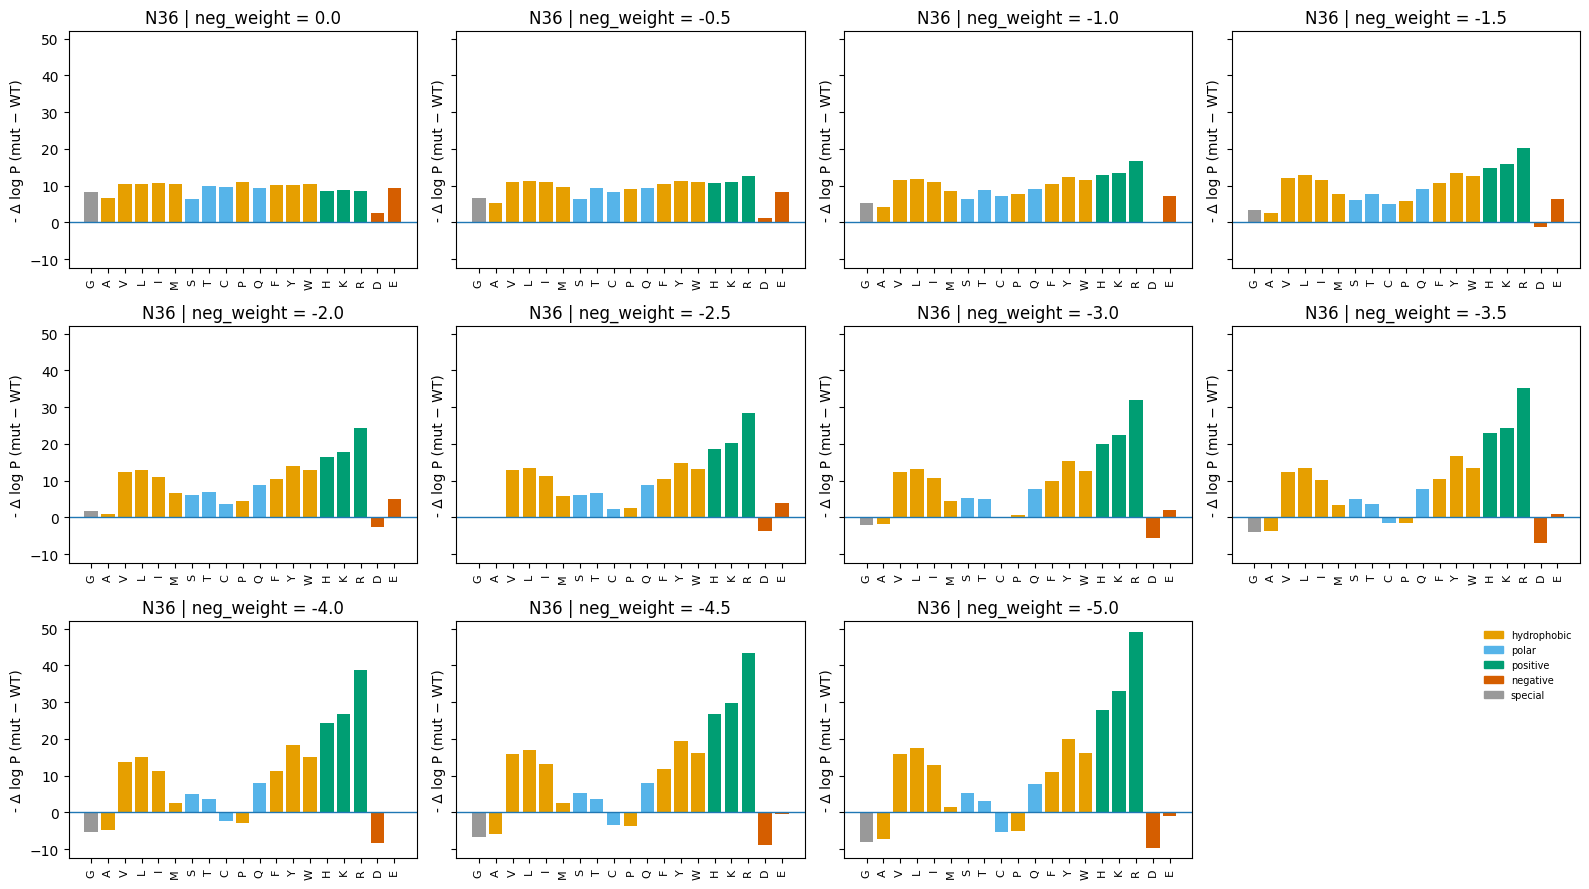

In [13]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# User parameters
# ----------------------------
pattern = "AB_full_mutation_table*.csv"
target_chain = "A"
target_pos = 31
ncols = 4
pdb_offset = 5  # for display only


# ----------------------------
# Load data
# ----------------------------
files = sorted(glob.glob(pattern))
if not files:
    raise FileNotFoundError(f"No files match pattern: {pattern}")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["neg_weight"] = pd.to_numeric(df["neg_weight"], errors="coerce")
df["pdb_resi"] = df["pdb_resi"].astype(int)

# ----------------------------
# Filter to target residue
# ----------------------------
df = df[
    (df["chain"] == target_chain) &
    (df["pdb_resi"] == target_pos)
].copy()

if df.empty:
    raise ValueError(f"No rows found for {target_chain}{target_pos}")

wt_aa = df["wt"].iloc[0]

# ----------------------------
# Use Δ log P already in CSV
# ----------------------------


plot_df = df[["neg_weight", "mut", "delta_logp"]].copy()

plot_df = plot_df[plot_df["mut"] != "WT"]

# Remove self-mutation (e.g., mut == "R" for R27)
plot_df = plot_df[plot_df["mut"] != wt_aa]
plot_df["delta_logp"] *= -1

aa_property = {
    # hydrophobic
    "A":"hydrophobic","V":"hydrophobic","L":"hydrophobic","I":"hydrophobic","M":"hydrophobic","F":"hydrophobic","W":"hydrophobic","Y":"hydrophobic","P":"hydrophobic",

    # polar
    "S":"polar","T":"polar","N":"polar","Q":"polar","C":"polar",

    # charged positive
    "K":"positive","R":"positive","H":"positive",

    # charged negative
    "D":"negative","E":"negative",

    # special
    "G":"special",
}

prop_colors = {
    "hydrophobic": "#E69F00",   # orange
    "polar": "#56B4E9",         # blue
    "positive": "#009E73",      # green
    "negative": "#D55E00",      # red
    "special": "#999999"        # gray
}

plot_df["property"] = plot_df["mut"].map(aa_property)
plot_df["color"] = plot_df["property"].map(prop_colors)


aa_order = [
    "WT", "G", "A", "V", "L", "I", "M",
    "S", "T", "C", "P", "N", "Q",
    "F", "Y", "W",
    "H", "K", "R",
    "D", "E"
]

plot_df["mut"] = pd.Categorical(
    plot_df["mut"],
    categories=aa_order,
    ordered=True
)



# ----------------------------
# Faceted bar plot by neg_weight
# ----------------------------
weights = (
    plot_df["neg_weight"]
    .dropna()
    .astype(float)
    .sort_values(ascending=False)  # ← reverse order
    .unique()
)


nrows = int(np.ceil(len(weights) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4 * ncols, 3 * nrows),
    sharey=True
)
axes = axes.flatten()

for ax, w in zip(axes, weights):
    sub = (
    plot_df[plot_df["neg_weight"] == w]
    .sort_values("mut")
    )

    if sub.empty:
        ax.axis("off")
        continue

    x = np.arange(len(sub))

    ax.bar(x, sub["delta_logp"], color=sub["color"])



    display_pos = target_pos + pdb_offset
    ax.set_title(f"{wt_aa}{display_pos} | neg_weight = {w}")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["mut"], rotation=90, fontsize=8)



    ax.axhline(0, linewidth=1)
    ax.set_ylabel("- Δ log P (mut − WT)")

# Turn off unused axes
for ax in axes[len(weights):]:
    ax.axis("off")

legend_handles = [
    Patch(color=c, label=p) for p, c in prop_colors.items()
]

ax.legend(
    handles=legend_handles,
    fontsize=7,
    frameon=False,
    loc="upper right"
)


fig.tight_layout()
plt.show()


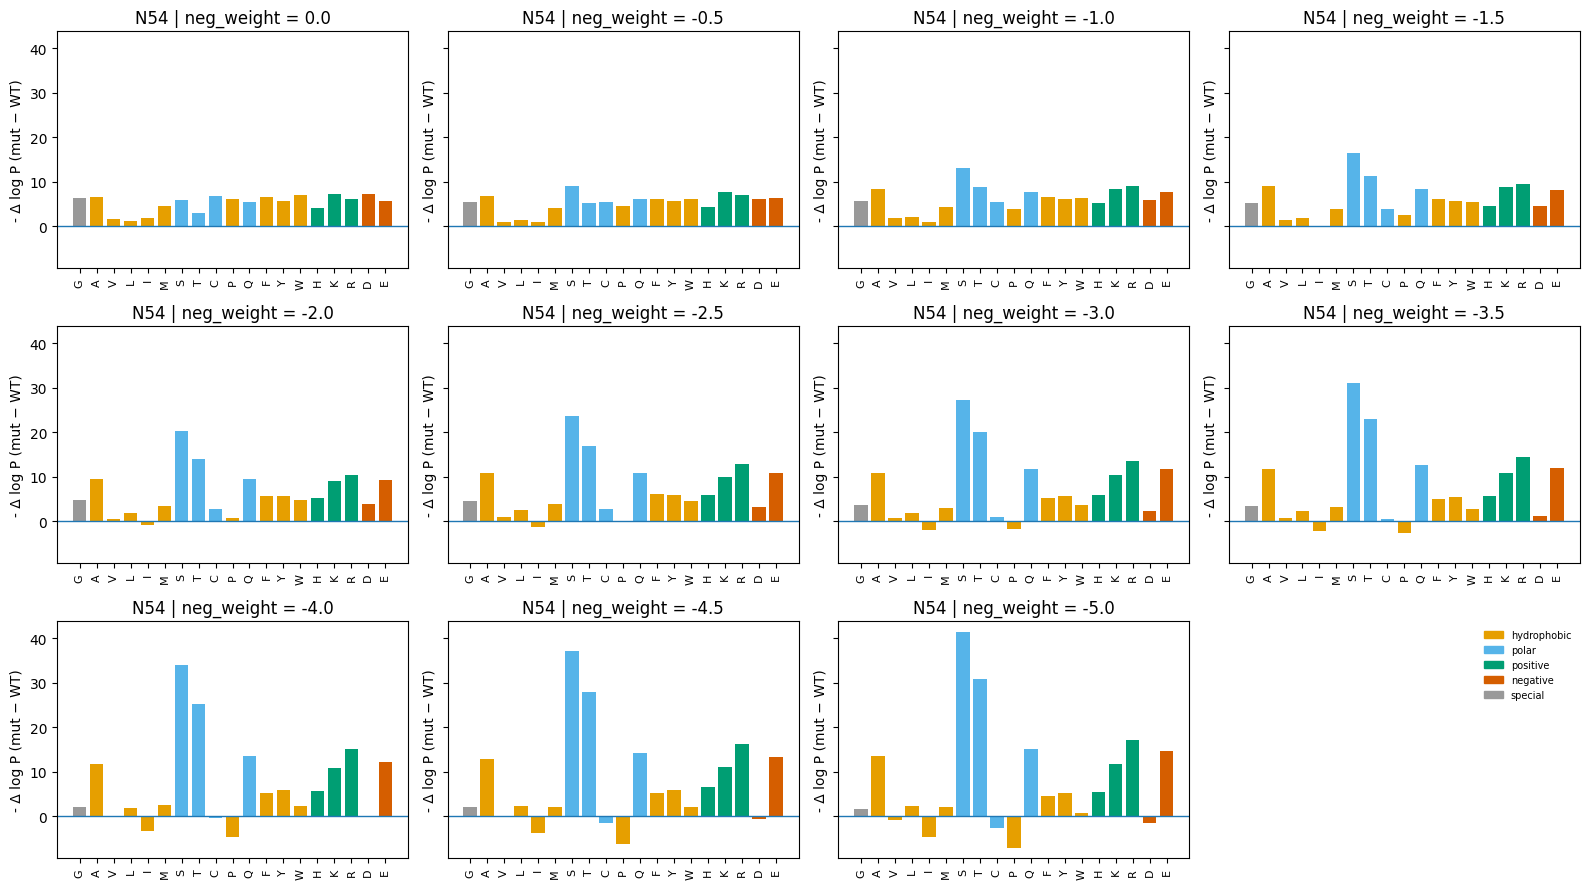

In [14]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# User parameters
# ----------------------------
pattern = "AB_full_mutation_table*.csv"
target_chain = "A"
target_pos = 49
ncols = 4
pdb_offset = 5  # for display only


# ----------------------------
# Load data
# ----------------------------
files = sorted(glob.glob(pattern))
if not files:
    raise FileNotFoundError(f"No files match pattern: {pattern}")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["neg_weight"] = pd.to_numeric(df["neg_weight"], errors="coerce")
df["pdb_resi"] = df["pdb_resi"].astype(int)

# ----------------------------
# Filter to target residue
# ----------------------------
df = df[
    (df["chain"] == target_chain) &
    (df["pdb_resi"] == target_pos)
].copy()

if df.empty:
    raise ValueError(f"No rows found for {target_chain}{target_pos}")

wt_aa = df["wt"].iloc[0]

# ----------------------------
# Use Δ log P already in CSV
# ----------------------------


plot_df = df[["neg_weight", "mut", "delta_logp"]].copy()

plot_df = plot_df[plot_df["mut"] != "WT"]

# Remove self-mutation (e.g., mut == "R" for R27)
plot_df = plot_df[plot_df["mut"] != wt_aa]
plot_df["delta_logp"] *= -1

aa_property = {
    # hydrophobic
    "A":"hydrophobic","V":"hydrophobic","L":"hydrophobic","I":"hydrophobic","M":"hydrophobic","F":"hydrophobic","W":"hydrophobic","Y":"hydrophobic","P":"hydrophobic",

    # polar
    "S":"polar","T":"polar","N":"polar","Q":"polar","C":"polar",

    # charged positive
    "K":"positive","R":"positive","H":"positive",

    # charged negative
    "D":"negative","E":"negative",

    # special
    "G":"special",
}

prop_colors = {
    "hydrophobic": "#E69F00",   # orange
    "polar": "#56B4E9",         # blue
    "positive": "#009E73",      # green
    "negative": "#D55E00",      # red
    "special": "#999999"        # gray
}

plot_df["property"] = plot_df["mut"].map(aa_property)
plot_df["color"] = plot_df["property"].map(prop_colors)


aa_order = [
    "WT", "G", "A", "V", "L", "I", "M",
    "S", "T", "C", "P", "N", "Q",
    "F", "Y", "W",
    "H", "K", "R",
    "D", "E"
]

plot_df["mut"] = pd.Categorical(
    plot_df["mut"],
    categories=aa_order,
    ordered=True
)



# ----------------------------
# Faceted bar plot by neg_weight
# ----------------------------
weights = (
    plot_df["neg_weight"]
    .dropna()
    .astype(float)
    .sort_values(ascending=False)  # ← reverse order
    .unique()
)


nrows = int(np.ceil(len(weights) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4 * ncols, 3 * nrows),
    sharey=True
)
axes = axes.flatten()

for ax, w in zip(axes, weights):
    sub = (
    plot_df[plot_df["neg_weight"] == w]
    .sort_values("mut")
    )

    if sub.empty:
        ax.axis("off")
        continue

    x = np.arange(len(sub))

    ax.bar(x, sub["delta_logp"], color=sub["color"])



    display_pos = target_pos + pdb_offset
    ax.set_title(f"{wt_aa}{display_pos} | neg_weight = {w}")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["mut"], rotation=90, fontsize=8)



    ax.axhline(0, linewidth=1)
    ax.set_ylabel("- Δ log P (mut − WT)")

# Turn off unused axes
for ax in axes[len(weights):]:
    ax.axis("off")

legend_handles = [
    Patch(color=c, label=p) for p, c in prop_colors.items()
]

ax.legend(
    handles=legend_handles,
    fontsize=7,
    frameon=False,
    loc="upper right"
)


fig.tight_layout()
plt.show()


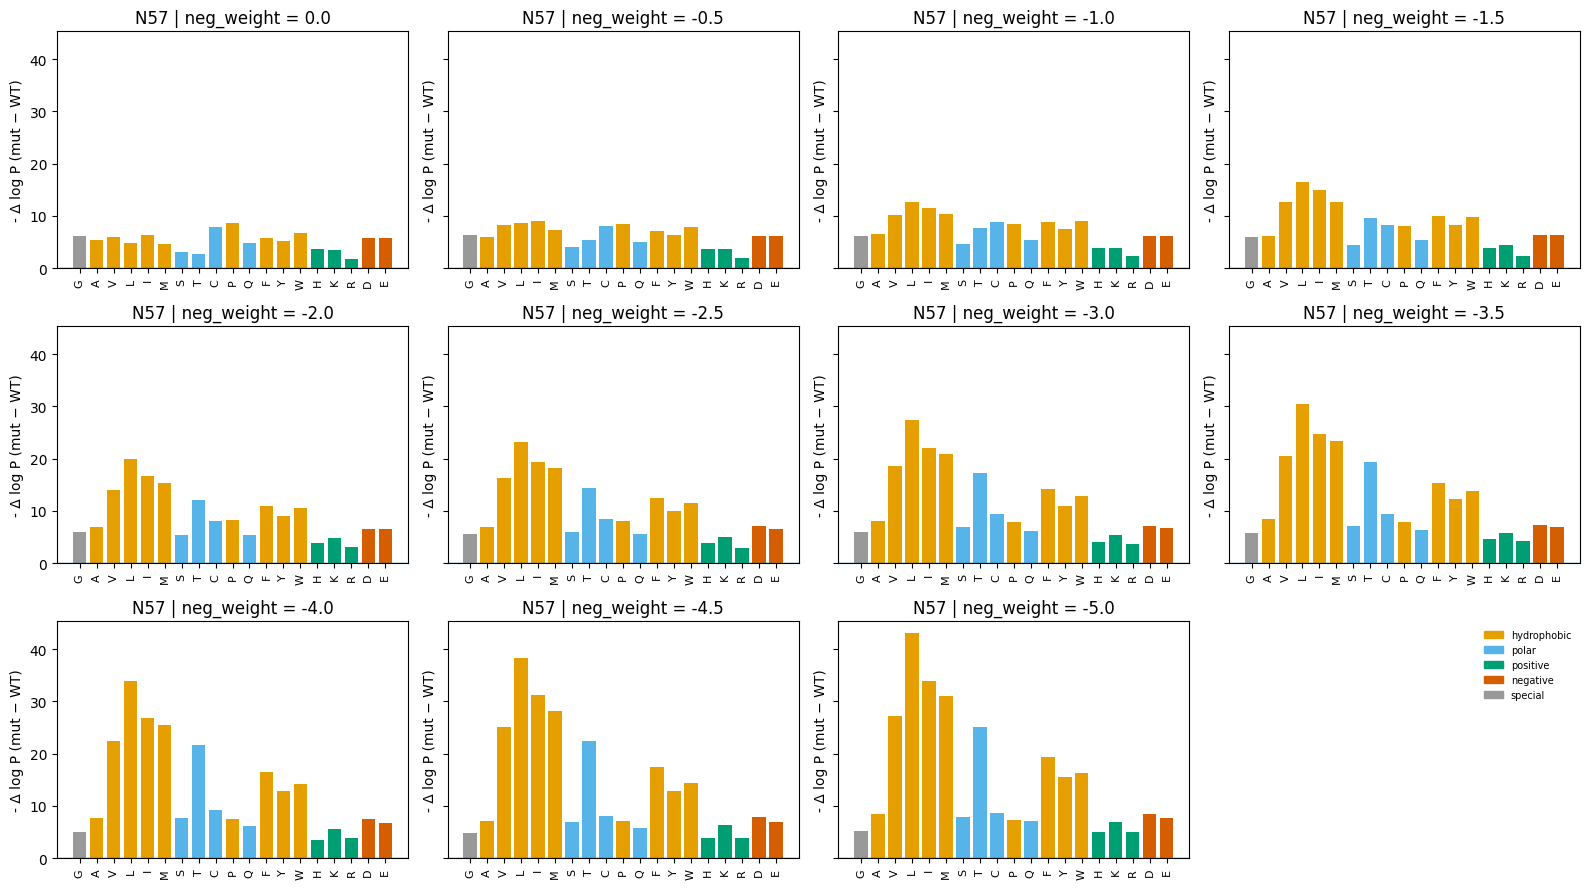

In [15]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# User parameters
# ----------------------------
pattern = "AB_full_mutation_table*.csv"
target_chain = "A"
target_pos = 52
ncols = 4
pdb_offset = 5  # for display only


# ----------------------------
# Load data
# ----------------------------
files = sorted(glob.glob(pattern))
if not files:
    raise FileNotFoundError(f"No files match pattern: {pattern}")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["neg_weight"] = pd.to_numeric(df["neg_weight"], errors="coerce")
df["pdb_resi"] = df["pdb_resi"].astype(int)

# ----------------------------
# Filter to target residue
# ----------------------------
df = df[
    (df["chain"] == target_chain) &
    (df["pdb_resi"] == target_pos)
].copy()

if df.empty:
    raise ValueError(f"No rows found for {target_chain}{target_pos}")

wt_aa = df["wt"].iloc[0]

# ----------------------------
# Use Δ log P already in CSV
# ----------------------------


plot_df = df[["neg_weight", "mut", "delta_logp"]].copy()

plot_df = plot_df[plot_df["mut"] != "WT"]

# Remove self-mutation (e.g., mut == "R" for R27)
plot_df = plot_df[plot_df["mut"] != wt_aa]
plot_df["delta_logp"] *= -1

aa_property = {
    # hydrophobic
    "A":"hydrophobic","V":"hydrophobic","L":"hydrophobic","I":"hydrophobic","M":"hydrophobic","F":"hydrophobic","W":"hydrophobic","Y":"hydrophobic","P":"hydrophobic",

    # polar
    "S":"polar","T":"polar","N":"polar","Q":"polar","C":"polar",

    # charged positive
    "K":"positive","R":"positive","H":"positive",

    # charged negative
    "D":"negative","E":"negative",

    # special
    "G":"special",
}

prop_colors = {
    "hydrophobic": "#E69F00",   # orange
    "polar": "#56B4E9",         # blue
    "positive": "#009E73",      # green
    "negative": "#D55E00",      # red
    "special": "#999999"        # gray
}

plot_df["property"] = plot_df["mut"].map(aa_property)
plot_df["color"] = plot_df["property"].map(prop_colors)


aa_order = [
    "WT", "G", "A", "V", "L", "I", "M",
    "S", "T", "C", "P", "N", "Q",
    "F", "Y", "W",
    "H", "K", "R",
    "D", "E"
]

plot_df["mut"] = pd.Categorical(
    plot_df["mut"],
    categories=aa_order,
    ordered=True
)



# ----------------------------
# Faceted bar plot by neg_weight
# ----------------------------
weights = (
    plot_df["neg_weight"]
    .dropna()
    .astype(float)
    .sort_values(ascending=False)  # ← reverse order
    .unique()
)


nrows = int(np.ceil(len(weights) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4 * ncols, 3 * nrows),
    sharey=True
)
axes = axes.flatten()

for ax, w in zip(axes, weights):
    sub = (
    plot_df[plot_df["neg_weight"] == w]
    .sort_values("mut")
    )

    if sub.empty:
        ax.axis("off")
        continue

    x = np.arange(len(sub))

    ax.bar(x, sub["delta_logp"], color=sub["color"])



    display_pos = target_pos + pdb_offset
    ax.set_title(f"{wt_aa}{display_pos} | neg_weight = {w}")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["mut"], rotation=90, fontsize=8)



    ax.axhline(0, linewidth=1)
    ax.set_ylabel("- Δ log P (mut − WT)")

# Turn off unused axes
for ax in axes[len(weights):]:
    ax.axis("off")

legend_handles = [
    Patch(color=c, label=p) for p, c in prop_colors.items()
]

ax.legend(
    handles=legend_handles,
    fontsize=7,
    frameon=False,
    loc="upper right"
)


fig.tight_layout()
plt.show()


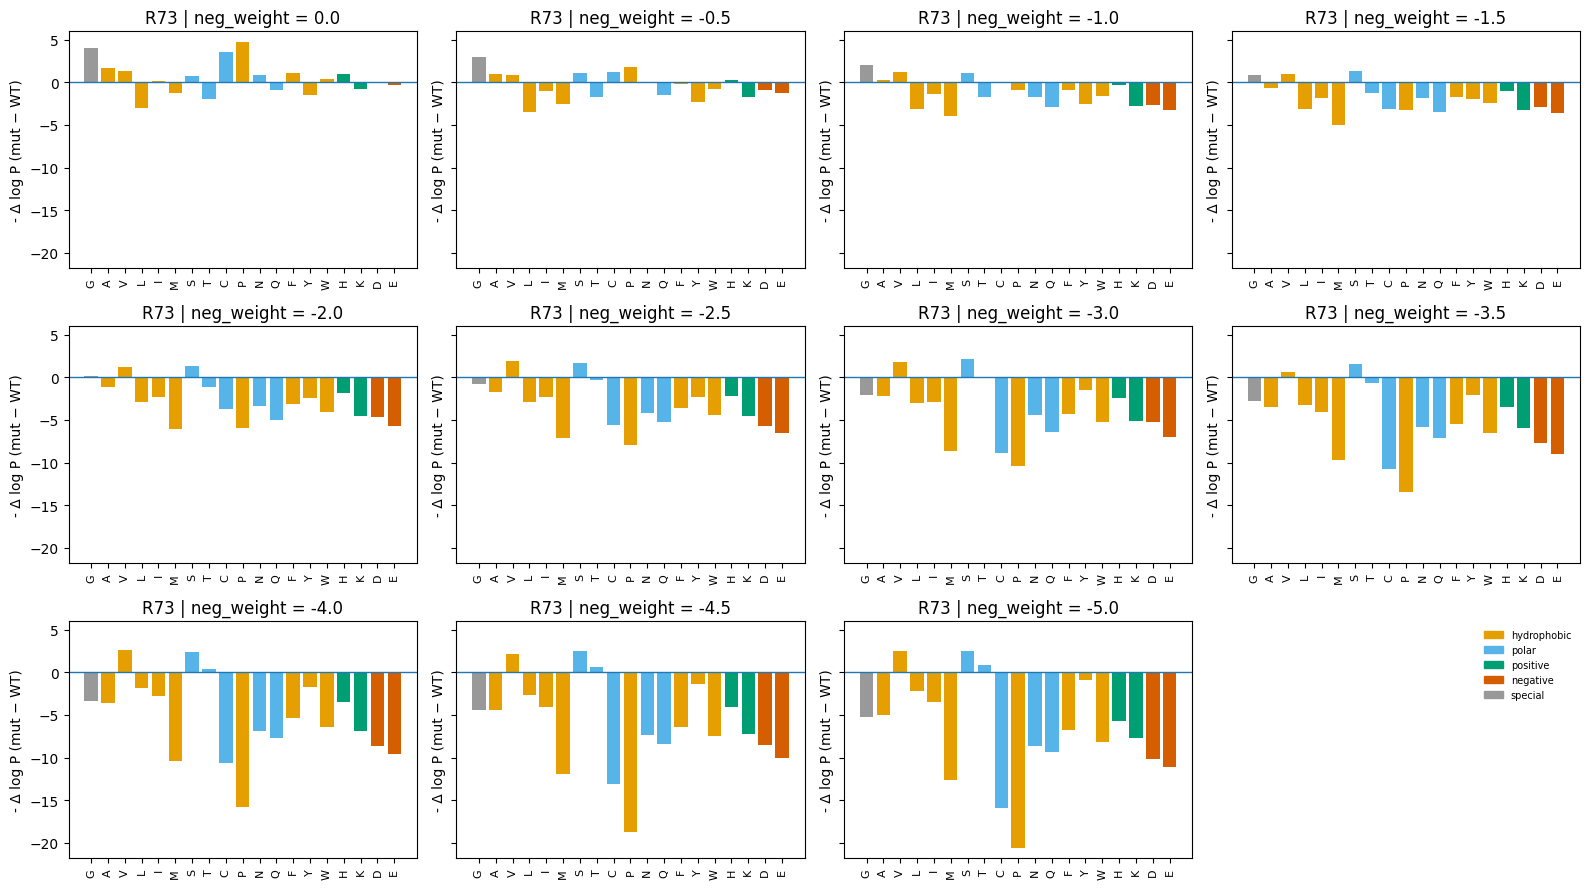

In [16]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# User parameters
# ----------------------------
pattern = "AB_full_mutation_table*.csv"
target_chain = "A"
target_pos = 68
ncols = 4
pdb_offset = 5  # for display only


# ----------------------------
# Load data
# ----------------------------
files = sorted(glob.glob(pattern))
if not files:
    raise FileNotFoundError(f"No files match pattern: {pattern}")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["neg_weight"] = pd.to_numeric(df["neg_weight"], errors="coerce")
df["pdb_resi"] = df["pdb_resi"].astype(int)

# ----------------------------
# Filter to target residue
# ----------------------------
df = df[
    (df["chain"] == target_chain) &
    (df["pdb_resi"] == target_pos)
].copy()

if df.empty:
    raise ValueError(f"No rows found for {target_chain}{target_pos}")

wt_aa = df["wt"].iloc[0]

# ----------------------------
# Use Δ log P already in CSV
# ----------------------------


plot_df = df[["neg_weight", "mut", "delta_logp"]].copy()

plot_df = plot_df[plot_df["mut"] != "WT"]

# Remove self-mutation (e.g., mut == "R" for R27)
plot_df = plot_df[plot_df["mut"] != wt_aa]
plot_df["delta_logp"] *= -1

aa_property = {
    # hydrophobic
    "A":"hydrophobic","V":"hydrophobic","L":"hydrophobic","I":"hydrophobic","M":"hydrophobic","F":"hydrophobic","W":"hydrophobic","Y":"hydrophobic","P":"hydrophobic",

    # polar
    "S":"polar","T":"polar","N":"polar","Q":"polar","C":"polar",

    # charged positive
    "K":"positive","R":"positive","H":"positive",

    # charged negative
    "D":"negative","E":"negative",

    # special
    "G":"special",
}

prop_colors = {
    "hydrophobic": "#E69F00",   # orange
    "polar": "#56B4E9",         # blue
    "positive": "#009E73",      # green
    "negative": "#D55E00",      # red
    "special": "#999999"        # gray
}

plot_df["property"] = plot_df["mut"].map(aa_property)
plot_df["color"] = plot_df["property"].map(prop_colors)


aa_order = [
    "WT", "G", "A", "V", "L", "I", "M",
    "S", "T", "C", "P", "N", "Q",
    "F", "Y", "W",
    "H", "K", "R",
    "D", "E"
]

plot_df["mut"] = pd.Categorical(
    plot_df["mut"],
    categories=aa_order,
    ordered=True
)



# ----------------------------
# Faceted bar plot by neg_weight
# ----------------------------
weights = (
    plot_df["neg_weight"]
    .dropna()
    .astype(float)
    .sort_values(ascending=False)  # ← reverse order
    .unique()
)


nrows = int(np.ceil(len(weights) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4 * ncols, 3 * nrows),
    sharey=True
)
axes = axes.flatten()

for ax, w in zip(axes, weights):
    sub = (
    plot_df[plot_df["neg_weight"] == w]
    .sort_values("mut")
    )

    if sub.empty:
        ax.axis("off")
        continue

    x = np.arange(len(sub))

    ax.bar(x, sub["delta_logp"], color=sub["color"])



    display_pos = target_pos + pdb_offset
    ax.set_title(f"{wt_aa}{display_pos} | neg_weight = {w}")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["mut"], rotation=90, fontsize=8)



    ax.axhline(0, linewidth=1)
    ax.set_ylabel("- Δ log P (mut − WT)")

# Turn off unused axes
for ax in axes[len(weights):]:
    ax.axis("off")

legend_handles = [
    Patch(color=c, label=p) for p, c in prop_colors.items()
]

ax.legend(
    handles=legend_handles,
    fontsize=7,
    frameon=False,
    loc="upper right"
)


fig.tight_layout()
plt.show()


# Delta logp  Mutation Scans for Each Residue (Positive Weights)

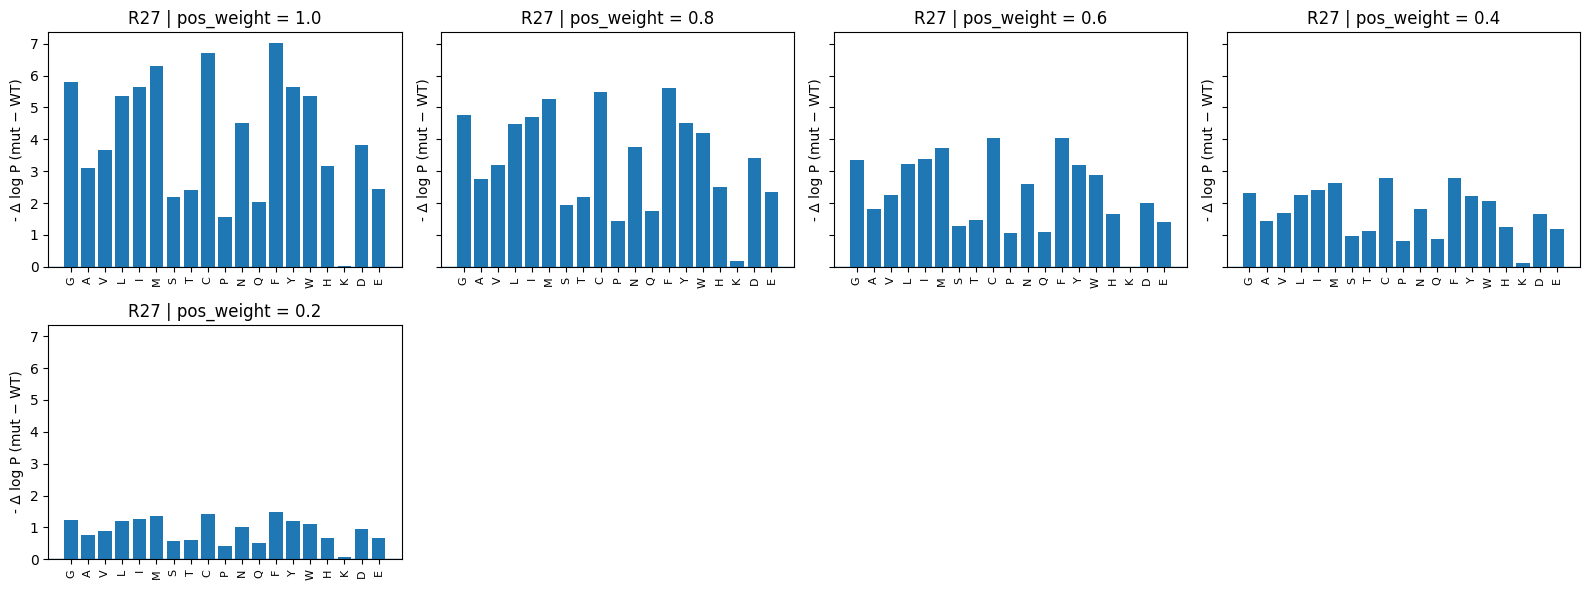

In [17]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# User parameters
# ----------------------------
pattern = "posAB_full_mutation_table*.csv"
target_chain = "A"
target_pos = 22
ncols = 4
pdb_offset = 5  # for display only

# ----------------------------
# Load data
# ----------------------------
files = sorted(glob.glob(pattern))
if not files:
    raise FileNotFoundError(f"No files match pattern: {pattern}")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["pos_weight"] = pd.to_numeric(df["pos_weight"], errors="coerce")
df["pdb_resi"] = df["pdb_resi"].astype(int)

# ----------------------------
# Filter to target residue
# ----------------------------
df = df[
    (df["chain"] == target_chain) &
    (df["pdb_resi"] == target_pos)
].copy()

if df.empty:
    raise ValueError(f"No rows found for {target_chain}{target_pos}")

wt_aa = df["wt"].iloc[0]

# ----------------------------
# Use Δ log P already in CSV
# ----------------------------
plot_df = df[["pos_weight", "mut", "delta_logp"]].copy()

plot_df = plot_df[plot_df["mut"] != "WT"]

# Remove self-mutation (e.g., mut == "R" for R27)
plot_df = plot_df[plot_df["mut"] != wt_aa]
plot_df["delta_logp"] *= -1

# Amino-acid ordering

aa_order = [
    "WT", "G", "A", "V", "L", "I", "M",
    "S", "T", "C", "P", "N", "Q",
    "F", "Y", "W",
    "H", "K", "R",
    "D", "E"
]

plot_df["mut"] = pd.Categorical(
    plot_df["mut"],
    categories=aa_order,
    ordered=True
)

# ----------------------------
# Faceted bar plot by neg_weight
# ----------------------------
weights = (
    plot_df["pos_weight"]
    .dropna()
    .astype(float)
    .sort_values(ascending=False)  # ← reverse order
    .unique()
)

nrows = int(np.ceil(len(weights) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4 * ncols, 3 * nrows),
    sharey=True
)
axes = axes.flatten()

for ax, w in zip(axes, weights):
    sub = (
        plot_df[plot_df["pos_weight"] == w]
        .sort_values("mut")
    )

    if sub.empty:
        ax.axis("off")
        continue

    ax.bar(
        sub["mut"],
        sub["delta_logp"],
        color="tab:blue"
    )

    display_pos = target_pos + pdb_offset
    ax.set_title(f"{wt_aa}{display_pos} | pos_weight = {w}")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["mut"].astype(str), rotation=90, fontsize=8)


    ax.axhline(0, linewidth=1)
    ax.set_ylabel("- Δ log P (mut − WT)")

# Turn off unused axes
for ax in axes[len(weights):]:
    ax.axis("off")

fig.tight_layout()
plt.show()

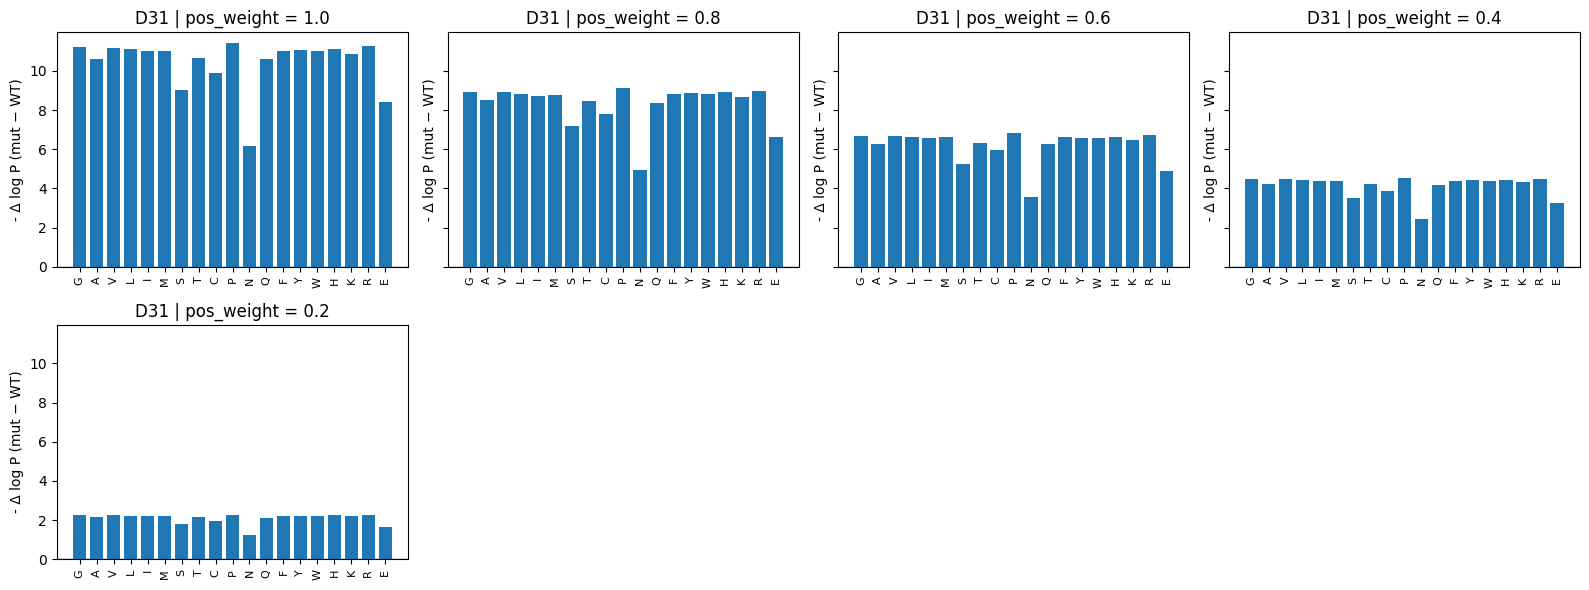

In [18]:
# ----------------------------
# User parameters
# ----------------------------
pattern = "posAB_full_mutation_table*.csv"
target_chain = "A"
target_pos = 26
ncols = 4
pdb_offset = 5  # for display only

# ----------------------------
# Load data
# ----------------------------
files = sorted(glob.glob(pattern))
if not files:
    raise FileNotFoundError(f"No files match pattern: {pattern}")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["pos_weight"] = pd.to_numeric(df["pos_weight"], errors="coerce")
df["pdb_resi"] = df["pdb_resi"].astype(int)

# ----------------------------
# Filter to target residue
# ----------------------------
df = df[
    (df["chain"] == target_chain) &
    (df["pdb_resi"] == target_pos)
].copy()

if df.empty:
    raise ValueError(f"No rows found for {target_chain}{target_pos}")

wt_aa = df["wt"].iloc[0]

# ----------------------------
# Use Δ log P already in CSV
# ----------------------------
plot_df = df[["pos_weight", "mut", "delta_logp"]].copy()

plot_df = plot_df[plot_df["mut"] != "WT"]

# Remove self-mutation (e.g., mut == "R" for R27)
plot_df = plot_df[plot_df["mut"] != wt_aa]
plot_df["delta_logp"] *= -1

# Amino-acid ordering

aa_order = [
    "WT", "G", "A", "V", "L", "I", "M",
    "S", "T", "C", "P", "N", "Q",
    "F", "Y", "W",
    "H", "K", "R",
    "D", "E"
]

plot_df["mut"] = pd.Categorical(
    plot_df["mut"],
    categories=aa_order,
    ordered=True
)

# ----------------------------
# Faceted bar plot by neg_weight
# ----------------------------
weights = (
    plot_df["pos_weight"]
    .dropna()
    .astype(float)
    .sort_values(ascending=False)  # ← reverse order
    .unique()
)
nrows = int(np.ceil(len(weights) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4 * ncols, 3 * nrows),
    sharey=True
)
axes = axes.flatten()

for ax, w in zip(axes, weights):
    sub = (
        plot_df[plot_df["pos_weight"] == w]
        .sort_values("mut")
    )

    if sub.empty:
        ax.axis("off")
        continue

    ax.bar(
        sub["mut"],
        sub["delta_logp"],
        color="tab:blue"
    )

    display_pos = target_pos + pdb_offset
    ax.set_title(f"{wt_aa}{display_pos} | pos_weight = {w}")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["mut"].astype(str), rotation=90, fontsize=8)


    ax.axhline(0, linewidth=1)
    ax.set_ylabel("- Δ log P (mut − WT)")

# Turn off unused axes
for ax in axes[len(weights):]:
    ax.axis("off")

fig.tight_layout()
plt.show()

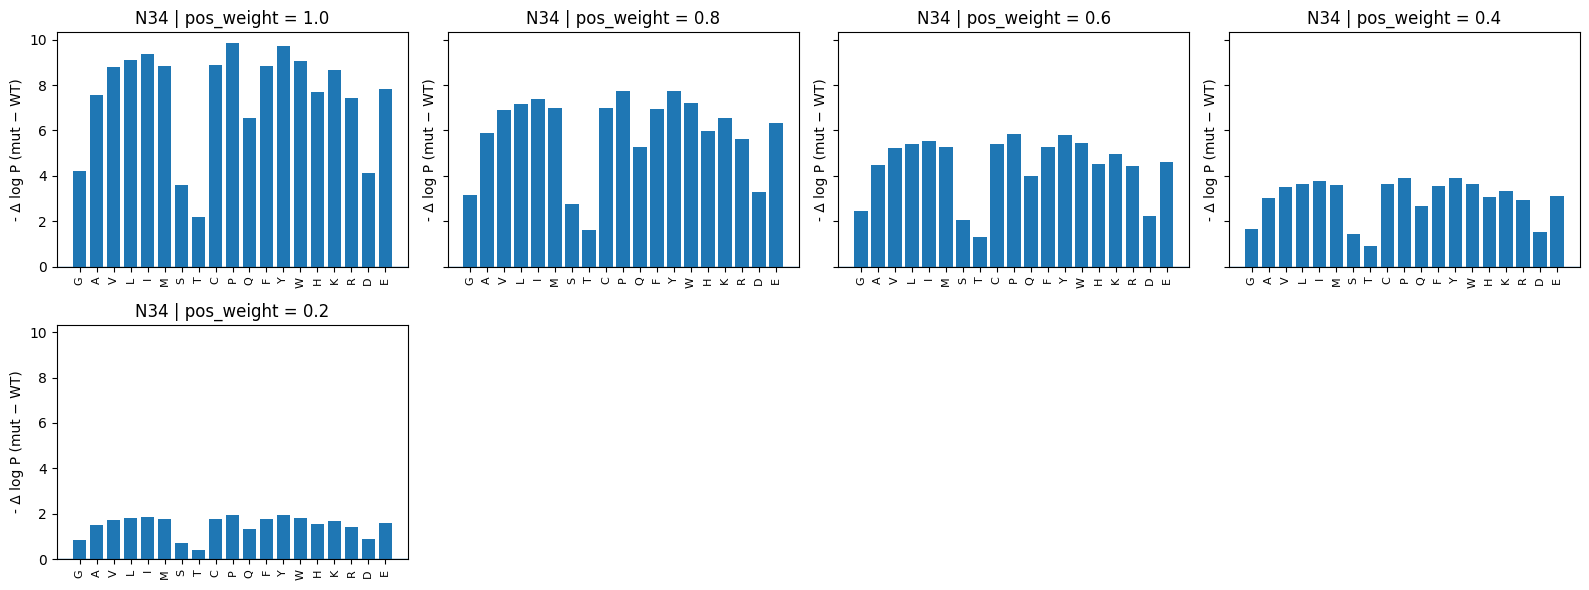

In [19]:
# ----------------------------
# User parameters
# ----------------------------
pattern = "posAB_full_mutation_table*.csv"
target_chain = "A"
target_pos = 29
ncols = 4
pdb_offset = 5  # for display only

# ----------------------------
# Load data
# ----------------------------
files = sorted(glob.glob(pattern))
if not files:
    raise FileNotFoundError(f"No files match pattern: {pattern}")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["pos_weight"] = pd.to_numeric(df["pos_weight"], errors="coerce")
df["pdb_resi"] = df["pdb_resi"].astype(int)

# ----------------------------
# Filter to target residue
# ----------------------------
df = df[
    (df["chain"] == target_chain) &
    (df["pdb_resi"] == target_pos)
].copy()

if df.empty:
    raise ValueError(f"No rows found for {target_chain}{target_pos}")

wt_aa = df["wt"].iloc[0]

# ----------------------------
# Use Δ log P already in CSV
# ----------------------------
plot_df = df[["pos_weight", "mut", "delta_logp"]].copy()

plot_df = plot_df[plot_df["mut"] != "WT"]

# Remove self-mutation (e.g., mut == "R" for R27)
plot_df = plot_df[plot_df["mut"] != wt_aa]
plot_df["delta_logp"] *= -1

# Amino-acid ordering

aa_order = [
    "WT", "G", "A", "V", "L", "I", "M",
    "S", "T", "C", "P", "N", "Q",
    "F", "Y", "W",
    "H", "K", "R",
    "D", "E"
]

plot_df["mut"] = pd.Categorical(
    plot_df["mut"],
    categories=aa_order,
    ordered=True
)

# ----------------------------
# Faceted bar plot by neg_weight
# ----------------------------
weights = (
    plot_df["pos_weight"]
    .dropna()
    .astype(float)
    .sort_values(ascending=False)  # ← reverse order
    .unique()
)
nrows = int(np.ceil(len(weights) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4 * ncols, 3 * nrows),
    sharey=True
)
axes = axes.flatten()

for ax, w in zip(axes, weights):
    sub = (
        plot_df[plot_df["pos_weight"] == w]
        .sort_values("mut")
    )

    if sub.empty:
        ax.axis("off")
        continue

    ax.bar(
        sub["mut"],
        sub["delta_logp"],
        color="tab:blue"
    )

    display_pos = target_pos + pdb_offset
    ax.set_title(f"{wt_aa}{display_pos} | pos_weight = {w}")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["mut"].astype(str), rotation=90, fontsize=8)


    ax.axhline(0, linewidth=1)
    ax.set_ylabel("- Δ log P (mut − WT)")

# Turn off unused axes
for ax in axes[len(weights):]:
    ax.axis("off")

fig.tight_layout()
plt.show()

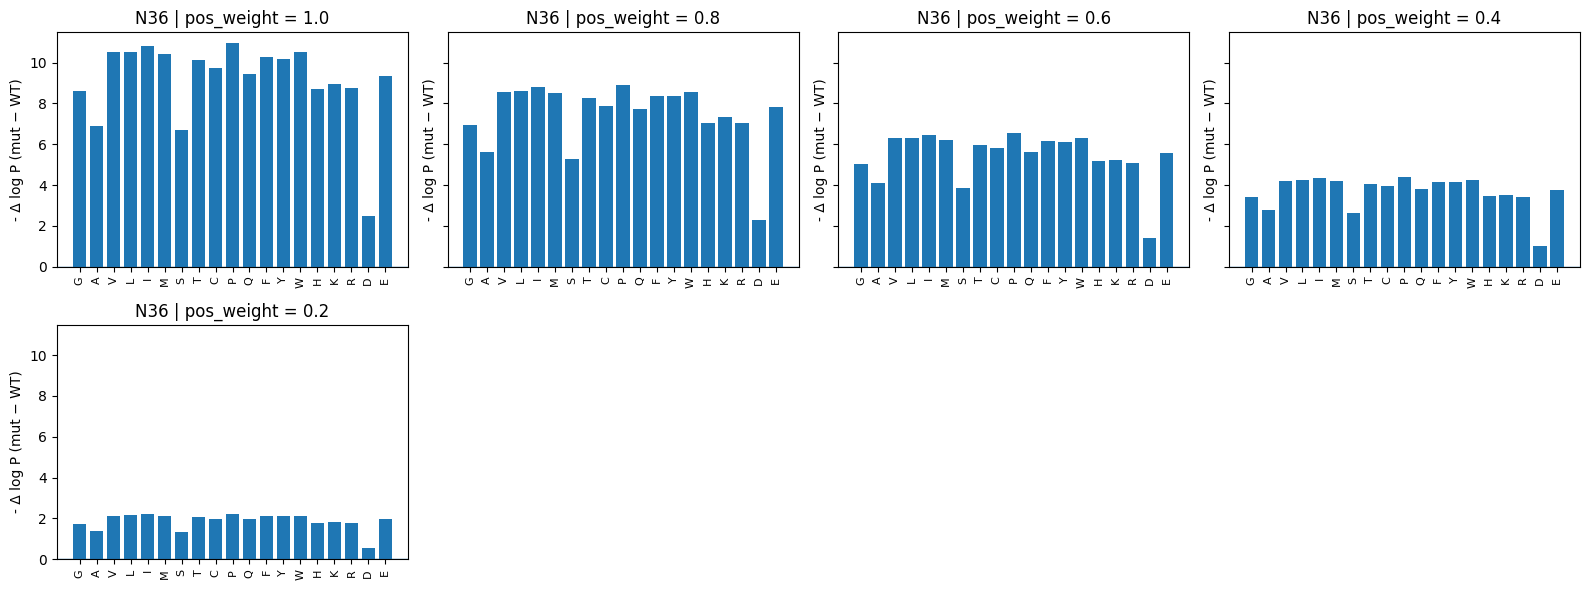

In [20]:
# ----------------------------
# User parameters
# ----------------------------
pattern = "posAB_full_mutation_table*.csv"
target_chain = "A"
target_pos = 31
ncols = 4
pdb_offset = 5  # for display only

# ----------------------------
# Load data
# ----------------------------
files = sorted(glob.glob(pattern))
if not files:
    raise FileNotFoundError(f"No files match pattern: {pattern}")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["pos_weight"] = pd.to_numeric(df["pos_weight"], errors="coerce")
df["pdb_resi"] = df["pdb_resi"].astype(int)

# ----------------------------
# Filter to target residue
# ----------------------------
df = df[
    (df["chain"] == target_chain) &
    (df["pdb_resi"] == target_pos)
].copy()

if df.empty:
    raise ValueError(f"No rows found for {target_chain}{target_pos}")

wt_aa = df["wt"].iloc[0]

# ----------------------------
# Use Δ log P already in CSV
# ----------------------------
plot_df = df[["pos_weight", "mut", "delta_logp"]].copy()

plot_df = plot_df[plot_df["mut"] != "WT"]

# Remove self-mutation (e.g., mut == "R" for R27)
plot_df = plot_df[plot_df["mut"] != wt_aa]
plot_df["delta_logp"] *= -1

# Amino-acid ordering

aa_order = [
    "WT", "G", "A", "V", "L", "I", "M",
    "S", "T", "C", "P", "N", "Q",
    "F", "Y", "W",
    "H", "K", "R",
    "D", "E"
]

plot_df["mut"] = pd.Categorical(
    plot_df["mut"],
    categories=aa_order,
    ordered=True
)

# ----------------------------
# Faceted bar plot by neg_weight
# ----------------------------
weights = (
    plot_df["pos_weight"]
    .dropna()
    .astype(float)
    .sort_values(ascending=False)  # ← reverse order
    .unique()
)
nrows = int(np.ceil(len(weights) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4 * ncols, 3 * nrows),
    sharey=True
)
axes = axes.flatten()

for ax, w in zip(axes, weights):
    sub = (
        plot_df[plot_df["pos_weight"] == w]
        .sort_values("mut")
    )

    if sub.empty:
        ax.axis("off")
        continue

    ax.bar(
        sub["mut"],
        sub["delta_logp"],
        color="tab:blue"
    )

    display_pos = target_pos + pdb_offset
    ax.set_title(f"{wt_aa}{display_pos} | pos_weight = {w}")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["mut"].astype(str), rotation=90, fontsize=8)


    ax.axhline(0, linewidth=1)
    ax.set_ylabel("- Δ log P (mut − WT)")

# Turn off unused axes
for ax in axes[len(weights):]:
    ax.axis("off")

fig.tight_layout()
plt.show()

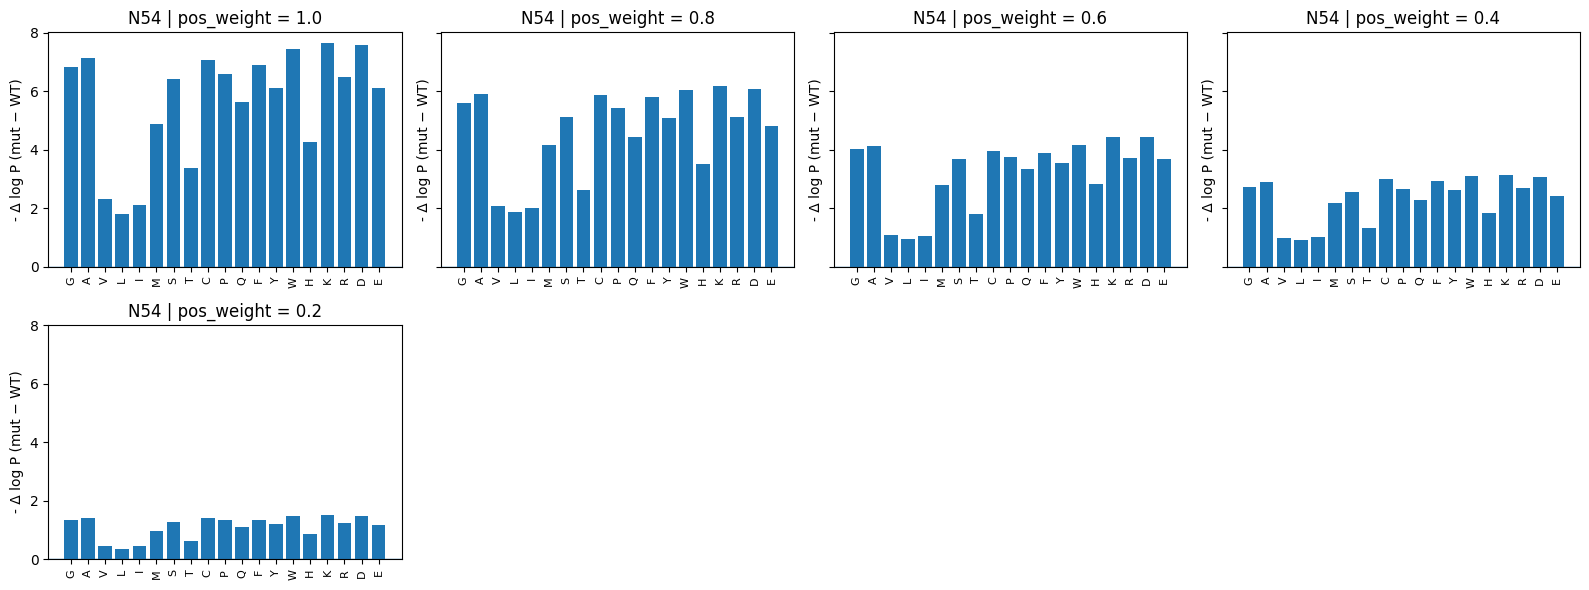

In [21]:
# ----------------------------
# User parameters
# ----------------------------
pattern = "posAB_full_mutation_table*.csv"
target_chain = "A"
target_pos = 49
ncols = 4
pdb_offset = 5  # for display only

# ----------------------------
# Load data
# ----------------------------
files = sorted(glob.glob(pattern))
if not files:
    raise FileNotFoundError(f"No files match pattern: {pattern}")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["pos_weight"] = pd.to_numeric(df["pos_weight"], errors="coerce")
df["pdb_resi"] = df["pdb_resi"].astype(int)

# ----------------------------
# Filter to target residue
# ----------------------------
df = df[
    (df["chain"] == target_chain) &
    (df["pdb_resi"] == target_pos)
].copy()

if df.empty:
    raise ValueError(f"No rows found for {target_chain}{target_pos}")

wt_aa = df["wt"].iloc[0]

# ----------------------------
# Use Δ log P already in CSV
# ----------------------------
plot_df = df[["pos_weight", "mut", "delta_logp"]].copy()

plot_df = plot_df[plot_df["mut"] != "WT"]

# Remove self-mutation (e.g., mut == "R" for R27)
plot_df = plot_df[plot_df["mut"] != wt_aa]
plot_df["delta_logp"] *= -1

# Amino-acid ordering

aa_order = [
    "WT", "G", "A", "V", "L", "I", "M",
    "S", "T", "C", "P", "N", "Q",
    "F", "Y", "W",
    "H", "K", "R",
    "D", "E"
]

plot_df["mut"] = pd.Categorical(
    plot_df["mut"],
    categories=aa_order,
    ordered=True
)

# ----------------------------
# Faceted bar plot by neg_weight
# ----------------------------
weights = (
    plot_df["pos_weight"]
    .dropna()
    .astype(float)
    .sort_values(ascending=False)  # ← reverse order
    .unique()
)
nrows = int(np.ceil(len(weights) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4 * ncols, 3 * nrows),
    sharey=True
)
axes = axes.flatten()

for ax, w in zip(axes, weights):
    sub = (
        plot_df[plot_df["pos_weight"] == w]
        .sort_values("mut")
    )

    if sub.empty:
        ax.axis("off")
        continue

    ax.bar(
        sub["mut"],
        sub["delta_logp"],
        color="tab:blue"
    )

    display_pos = target_pos + pdb_offset
    ax.set_title(f"{wt_aa}{display_pos} | pos_weight = {w}")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["mut"].astype(str), rotation=90, fontsize=8)


    ax.axhline(0, linewidth=1)
    ax.set_ylabel("- Δ log P (mut − WT)")

# Turn off unused axes
for ax in axes[len(weights):]:
    ax.axis("off")

fig.tight_layout()
plt.show()

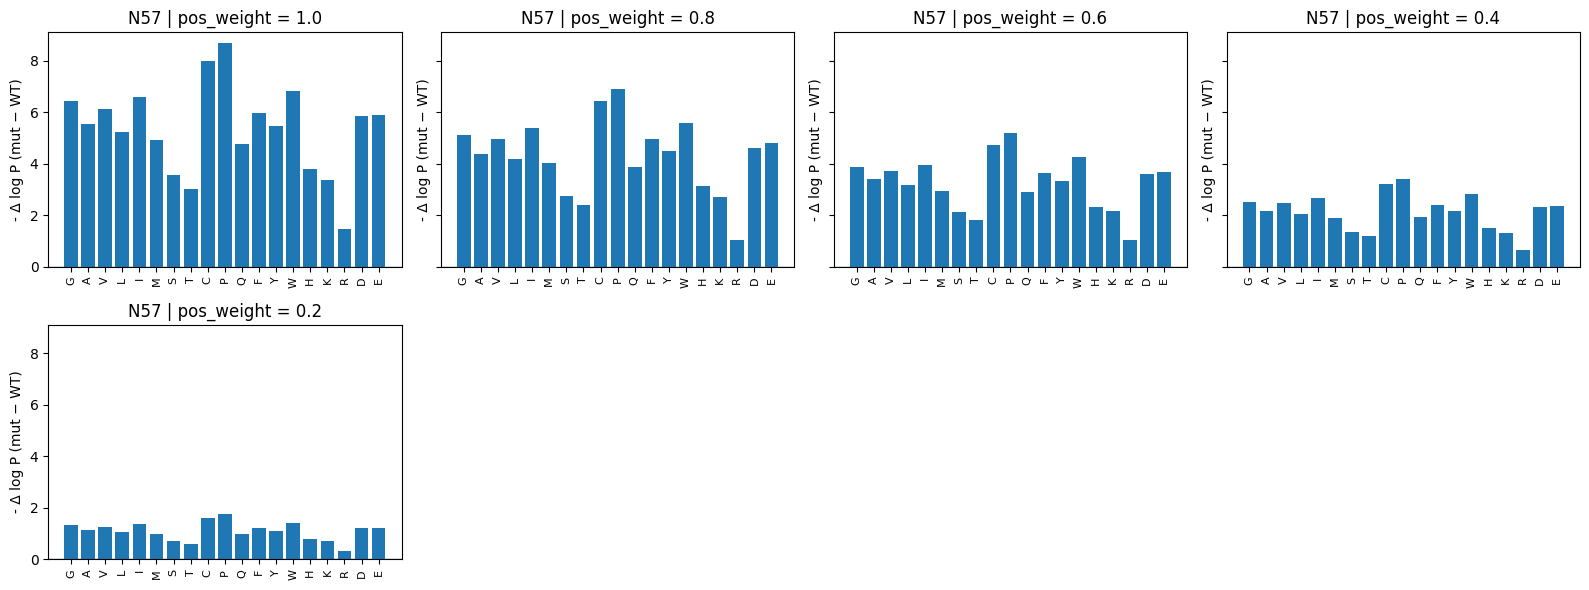

In [22]:
# ----------------------------
# User parameters
# ----------------------------
pattern = "posAB_full_mutation_table*.csv"
target_chain = "A"
target_pos = 52
ncols = 4
pdb_offset = 5  # for display only

# ----------------------------
# Load data
# ----------------------------
files = sorted(glob.glob(pattern))
if not files:
    raise FileNotFoundError(f"No files match pattern: {pattern}")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["pos_weight"] = pd.to_numeric(df["pos_weight"], errors="coerce")
df["pdb_resi"] = df["pdb_resi"].astype(int)

# ----------------------------
# Filter to target residue
# ----------------------------
df = df[
    (df["chain"] == target_chain) &
    (df["pdb_resi"] == target_pos)
].copy()

if df.empty:
    raise ValueError(f"No rows found for {target_chain}{target_pos}")

wt_aa = df["wt"].iloc[0]

# ----------------------------
# Use Δ log P already in CSV
# ----------------------------
plot_df = df[["pos_weight", "mut", "delta_logp"]].copy()

plot_df = plot_df[plot_df["mut"] != "WT"]

# Remove self-mutation (e.g., mut == "R" for R27)
plot_df = plot_df[plot_df["mut"] != wt_aa]
plot_df["delta_logp"] *= -1

# Amino-acid ordering

aa_order = [
    "WT", "G", "A", "V", "L", "I", "M",
    "S", "T", "C", "P", "N", "Q",
    "F", "Y", "W",
    "H", "K", "R",
    "D", "E"
]

plot_df["mut"] = pd.Categorical(
    plot_df["mut"],
    categories=aa_order,
    ordered=True
)

# ----------------------------
# Faceted bar plot by neg_weight
# ----------------------------
weights = (
    plot_df["pos_weight"]
    .dropna()
    .astype(float)
    .sort_values(ascending=False)  # ← reverse order
    .unique()
)
nrows = int(np.ceil(len(weights) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4 * ncols, 3 * nrows),
    sharey=True
)
axes = axes.flatten()

for ax, w in zip(axes, weights):
    sub = (
        plot_df[plot_df["pos_weight"] == w]
        .sort_values("mut")
    )

    if sub.empty:
        ax.axis("off")
        continue

    ax.bar(
        sub["mut"],
        sub["delta_logp"],
        color="tab:blue"
    )

    display_pos = target_pos + pdb_offset
    ax.set_title(f"{wt_aa}{display_pos} | pos_weight = {w}")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["mut"].astype(str), rotation=90, fontsize=8)


    ax.axhline(0, linewidth=1)
    ax.set_ylabel("- Δ log P (mut − WT)")

# Turn off unused axes
for ax in axes[len(weights):]:
    ax.axis("off")

fig.tight_layout()
plt.show()

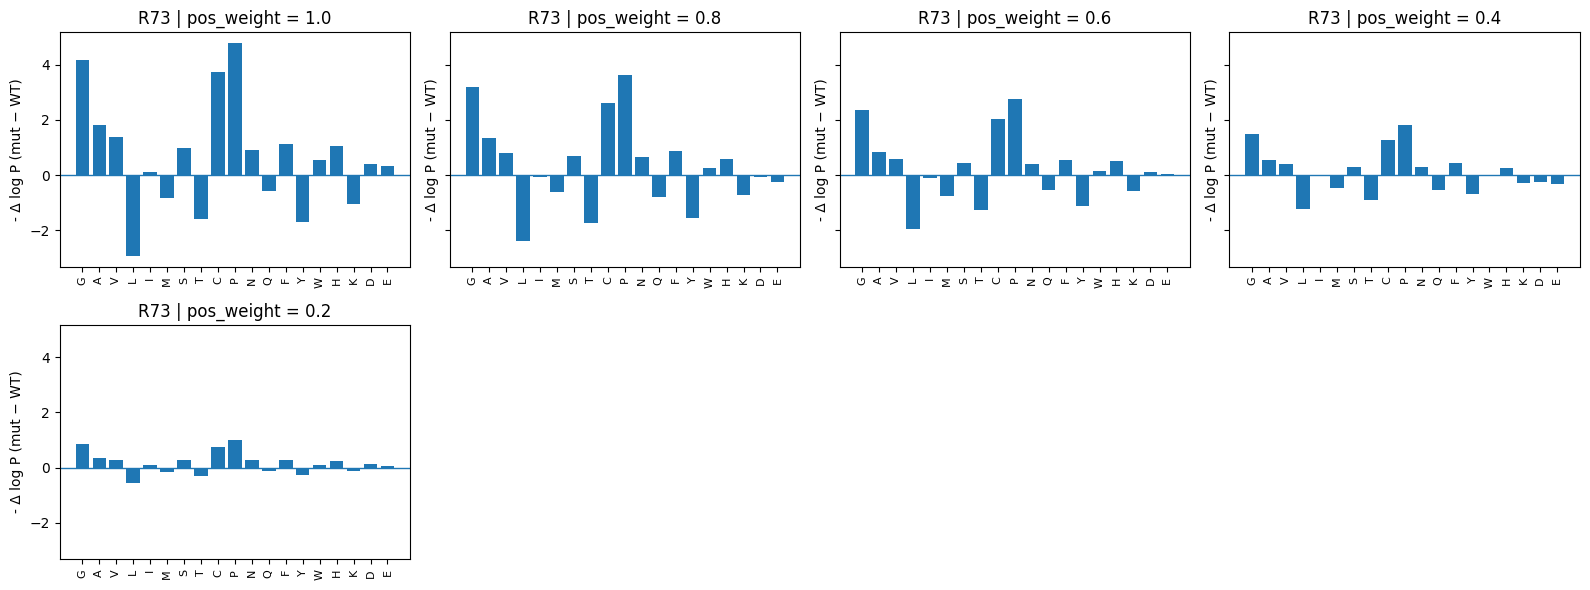

In [23]:
# ----------------------------
# User parameters
# ----------------------------
pattern = "posAB_full_mutation_table*.csv"
target_chain = "A"
target_pos = 68
ncols = 4
pdb_offset = 5  # for display only

# ----------------------------
# Load data
# ----------------------------
files = sorted(glob.glob(pattern))
if not files:
    raise FileNotFoundError(f"No files match pattern: {pattern}")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["pos_weight"] = pd.to_numeric(df["pos_weight"], errors="coerce")
df["pdb_resi"] = df["pdb_resi"].astype(int)

# ----------------------------
# Filter to target residue
# ----------------------------
df = df[
    (df["chain"] == target_chain) &
    (df["pdb_resi"] == target_pos)
].copy()

if df.empty:
    raise ValueError(f"No rows found for {target_chain}{target_pos}")

wt_aa = df["wt"].iloc[0]

# ----------------------------
# Use Δ log P already in CSV
# ----------------------------
plot_df = df[["pos_weight", "mut", "delta_logp"]].copy()

plot_df = plot_df[plot_df["mut"] != "WT"]

# Remove self-mutation (e.g., mut == "R" for R27)
plot_df = plot_df[plot_df["mut"] != wt_aa]
plot_df["delta_logp"] *= -1

# Amino-acid ordering

aa_order = [
    "WT", "G", "A", "V", "L", "I", "M",
    "S", "T", "C", "P", "N", "Q",
    "F", "Y", "W",
    "H", "K", "R",
    "D", "E"
]

plot_df["mut"] = pd.Categorical(
    plot_df["mut"],
    categories=aa_order,
    ordered=True
)

# ----------------------------
# Faceted bar plot by neg_weight
# ----------------------------
weights = (
    plot_df["pos_weight"]
    .dropna()
    .astype(float)
    .sort_values(ascending=False)  # ← reverse order
    .unique()
)
nrows = int(np.ceil(len(weights) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4 * ncols, 3 * nrows),
    sharey=True
)
axes = axes.flatten()

for ax, w in zip(axes, weights):
    sub = (
        plot_df[plot_df["pos_weight"] == w]
        .sort_values("mut")
    )

    if sub.empty:
        ax.axis("off")
        continue

    ax.bar(
        sub["mut"],
        sub["delta_logp"],
        color="tab:blue"
    )

    display_pos = target_pos + pdb_offset
    ax.set_title(f"{wt_aa}{display_pos} | pos_weight = {w}")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["mut"].astype(str), rotation=90, fontsize=8)


    ax.axhline(0, linewidth=1)
    ax.set_ylabel("- Δ log P (mut − WT)")

# Turn off unused axes
for ax in axes[len(weights):]:
    ax.axis("off")

fig.tight_layout()
plt.show()

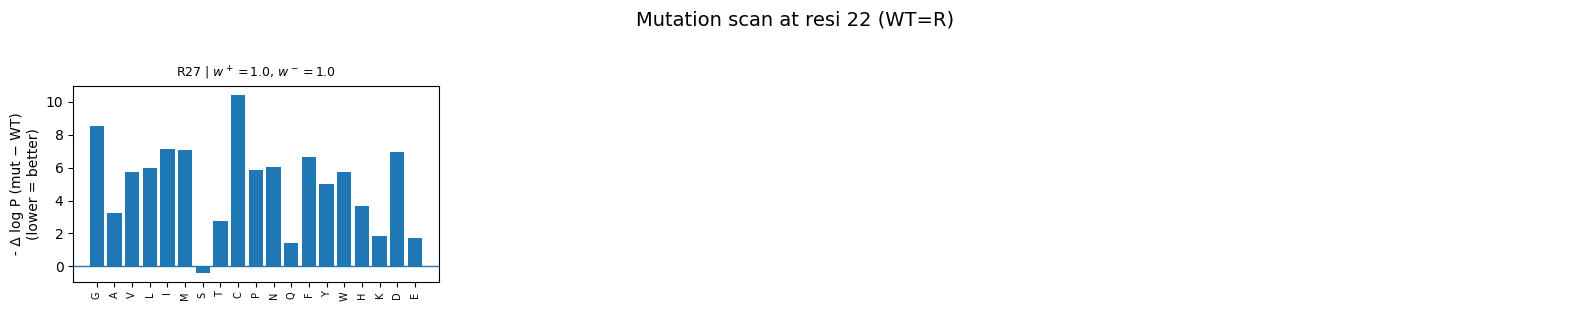

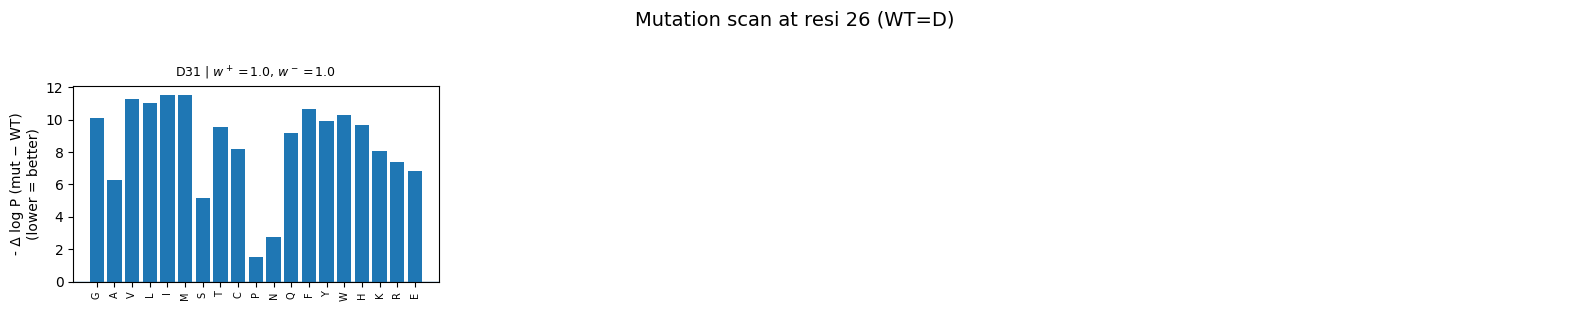

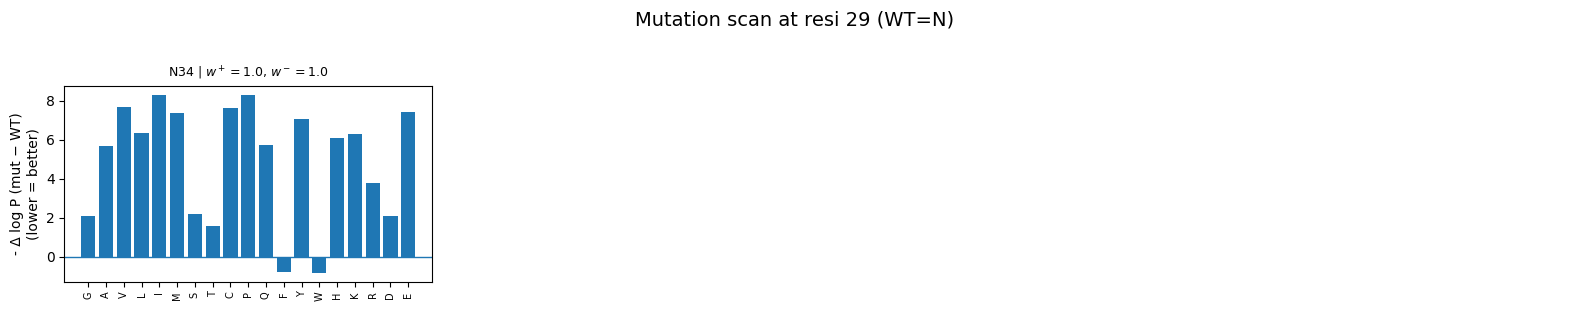

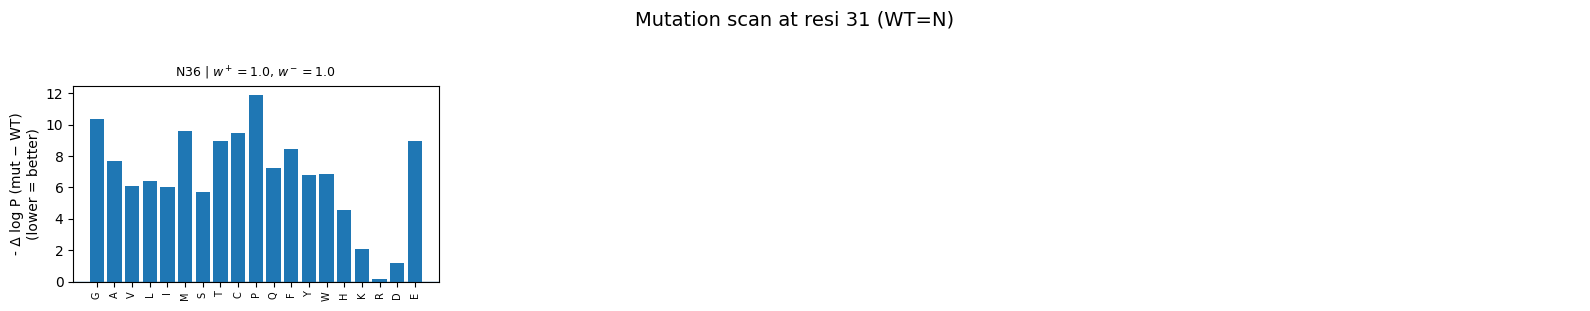

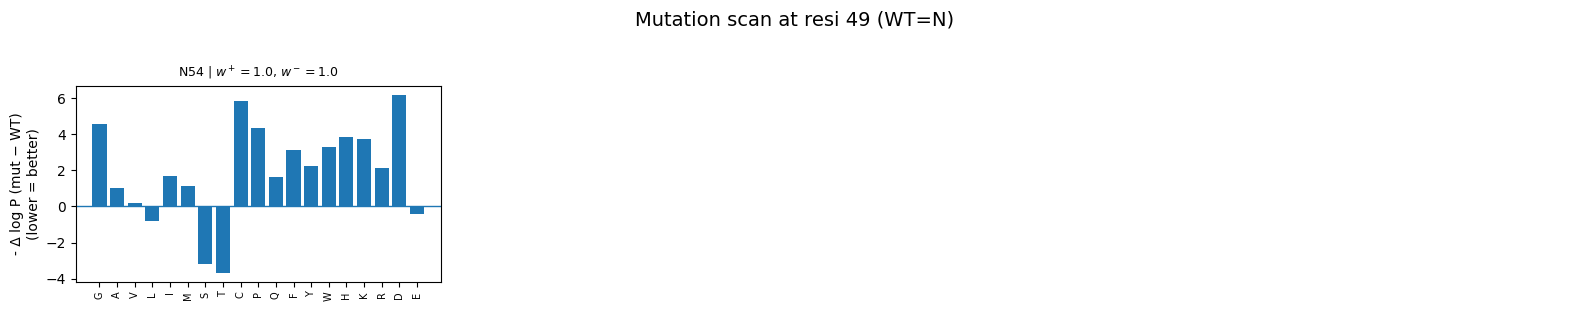

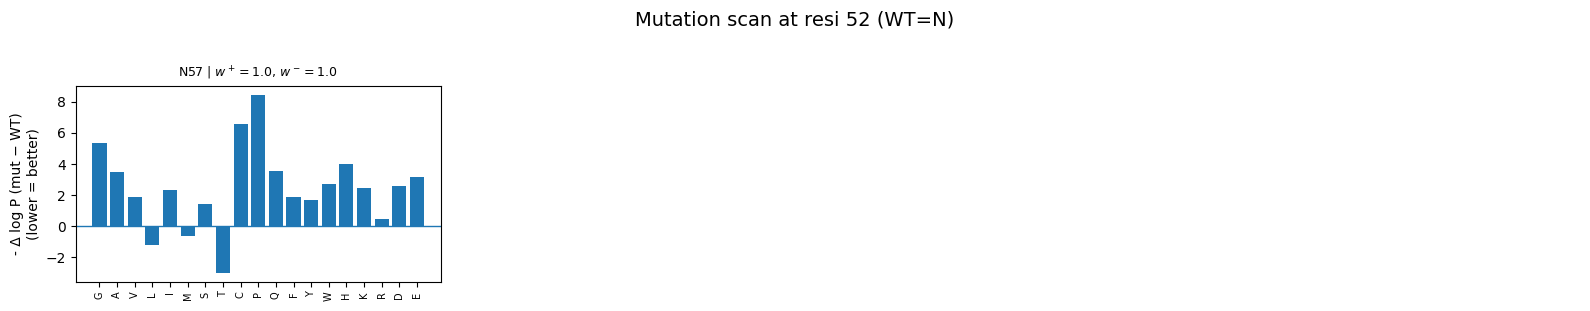

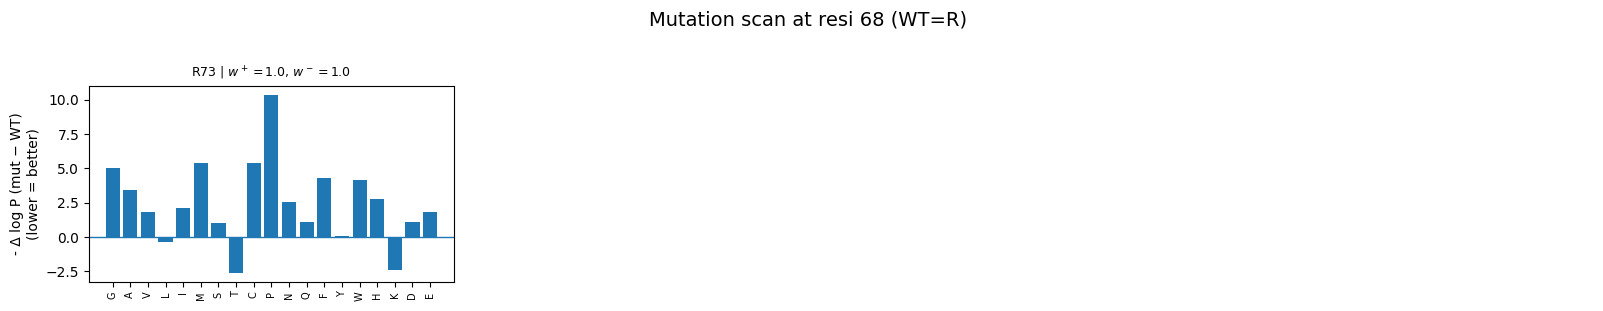

In [24]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# User parameters
# ----------------------------
pattern = "balanceAB_full_mutation_table*.csv"
target_chain = "A"
ncols = 4
pdb_offset = 5

# ----------------------------
# Load data
# ----------------------------
files = sorted(glob.glob(pattern))
if not files:
    raise FileNotFoundError(f"No files match pattern: {pattern}")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["neg_weight"] = pd.to_numeric(df["neg_weight"], errors="coerce")
df["pos_weight"] = pd.to_numeric(df["pos_weight"], errors="coerce")
df["pdb_resi"] = df["pdb_resi"].astype(int)

# ----------------------------
# Restrict to chain of interest
# ----------------------------
df = df[df["chain"] == target_chain].copy()
if df.empty:
    raise ValueError(f"No rows found for chain {target_chain}")

# ----------------------------
# Loop over residues
# ----------------------------
for pdb_resi, res_df in df.groupby("pdb_resi"):

    wt_aa = str(res_df["wt"].iloc[0])

    # ----------------------------
    # Build plotting dataframe
    # ----------------------------
    plot_df = res_df[["pos_weight", "neg_weight", "mut", "delta_logp"]].copy()

    # Remove explicit WT + self-mutation
    plot_df = plot_df[plot_df["mut"] != "WT"]
    plot_df = plot_df[plot_df["mut"] != wt_aa]
    plot_df["delta_logp"] *= -1
    if plot_df.empty:
        continue

    # Amino-acid ordering (exclude WT residue)
    
    aa_order = [
        "WT", "G", "A", "V", "L", "I", "M",
        "S", "T", "C", "P", "N", "Q",
        "F", "Y", "W",
        "H", "K", "R",
        "D", "E"
    ]
    plot_df["mut"] = pd.Categorical(
        plot_df["mut"],
        categories=aa_order,
        ordered=True
    )

    # ----------------------------
    # Build (pos, neg) facet list
    # ----------------------------
    pairs = (
        plot_df[["pos_weight", "neg_weight"]]
        .dropna()
        .drop_duplicates()
        .sort_values(["pos_weight", "neg_weight"])
        .to_records(index=False)
    )

    if len(pairs) == 0:
        continue

    nrows = int(np.ceil(len(pairs) / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4 * ncols, 3 * nrows),
        sharey=True
    )
    axes = np.array(axes).reshape(-1)

    # ----------------------------
    # Plot each (pos, neg) panel
    # ----------------------------
    for ax, (p, n) in zip(axes, pairs):
        sub = (
            plot_df[
                (plot_df["pos_weight"] == p) &
                (plot_df["neg_weight"] == n)
            ]
            .sort_values("mut")
        )

        if sub.empty:
            ax.axis("off")
            continue

        ax.bar(range(len(sub)), sub["delta_logp"], color="tab:blue")
        ax.axhline(0, linewidth=1)

        display_pos = pdb_resi + pdb_offset
        ax.set_title(
            rf"{wt_aa}{display_pos} | $w^+={p}$, $w^-={n}$",
            fontsize=9
        )

        ax.set_xticks(range(len(sub)))
        ax.set_xticklabels(sub["mut"].astype(str), rotation=90, fontsize=7)

        ax.set_ylabel("- Δ log P (mut − WT)\n(lower = better)")

    # Turn off unused axes
    for ax in axes[len(pairs):]:
        ax.axis("off")

    fig.suptitle(
        f"Mutation scan at resi {pdb_resi} (WT={wt_aa})",
        y=1.02,
        fontsize=14
    )

    fig.tight_layout()
    plt.show()


# Chain Mapping and Tied Positions Mapping

In [25]:
df = pd.read_csv("local_global_interface_map.csv")
df.loc[df["is_interface"] == 1, "local_idx"] += 5

def highlight_interface(row):
    return [
        "background-color: #ADD8E6" if row["is_interface"] == 1 else ""
        for _ in row
    ]

styled_df = (
    df.style
      .apply(highlight_interface, axis=1)
      .set_properties(
          **{
              "text-align": "center",
              "border": "1px solid black",
          }
      )
      .set_table_styles([
          {
              "selector": "th",
              "props": [
                  ("background-color", "#f2f2f2"),
                  ("font-weight", "bold"),
                  ("text-align", "center"),
                  ("border", "1px solid black"),
              ],
          }
      ])
)

styled_df


,chain,local_idx,global_idx,is_interface
0,A,1,0,0
1,A,2,1,0
2,A,3,2,0
3,A,4,3,0
4,A,5,4,0
5,A,6,5,0
6,A,7,6,0
7,A,8,7,0
8,A,9,8,0
9,A,10,9,0


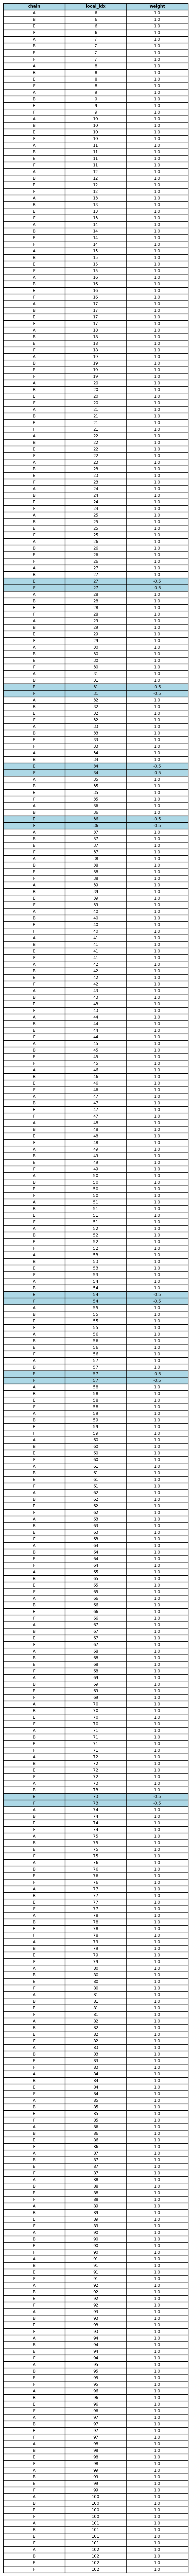

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("tied_positions_weights.csv")
df["local_idx"] += 5


fig, ax = plt.subplots(figsize=(6, 10))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc="center",
    loc="center"
)

# Formatting
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.2)

# Header styling
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#ADD8E6")

# 🔴 Highlight rows with negative weight
weight_col = df.columns.get_loc("weight")

for row_idx in range(len(df)):
    if df.iloc[row_idx]["weight"] < 0:
        for col_idx in range(len(df.columns)):
            table[(row_idx + 1, col_idx)].set_facecolor("#ADD8E6")
            
plt.suptitle("")
plt.show()


In [27]:
import pandas as pd
ortho = pd.read_csv('0.2orthonegweights_avg.csv')

In [28]:
ortho

,mutation,dG_interface,ddG_interface,dG_complex,ddG_complex,dG_receptor,ddG_receptor,dG_ligand,ddG_ligand
0,0.2_relaxed_ortho_3_A27K_A34T_A73L,-84.2442,-0.1998,-1296.3168,-7.8950,-714.4740,-0.2122,459.8068,-14.1072
1,0.2_relaxed_ortho_3_A27K_A73L,-81.8144,2.2300,-1294.7032,-6.2816,-714.1010,0.1610,459.0572,-14.8566
2,0.2_relaxed_ortho_3_A27K_A73Q,-80.4774,3.5668,-1291.8360,-3.4142,-714.0554,0.2064,465.1178,-8.7960
3,0.2_relaxed_ortho_3_A27K_A73T,-80.6600,3.3848,-1290.7746,-2.3526,-713.9438,0.3182,479.5610,5.6470
4,0.2_relaxed_ortho_3_A27K_B54I_A73L,-84.7756,-0.7306,-1293.1674,-4.7454,-713.2880,0.9740,461.1668,-12.7470
5,0.2_relaxed_ortho_3_A27K_B54L_A73L,-84.2310,-0.1866,-1295.2824,-6.8606,-713.7894,0.4726,469.8746,-4.0392
6,0.2_relaxed_ortho_3_A27Q_A34T_A73K,-81.8442,2.2004,-1290.5952,-2.1732,-714.5638,-0.3018,472.0440,-1.8698
7,0.2_relaxed_ortho_3_A27Q_B54L_A73L,-82.6654,1.3790,-1294.0004,-5.5786,-713.5660,0.6956,468.0616,-5.8522
8,0.2_relaxed_ortho_3_A73L,-83.8936,0.1510,-1297.0460,-8.6242,-714.2532,0.0088,458.8196,-15.0940
9,0.2_relaxed_ortho_3_A73T,-82.2570,1.7878,-1293.2648,-4.8428,-714.0588,0.2032,476.9128,2.9992


In [29]:
wt = pd.read_csv('0.2wtnegweights_avg.csv')

In [30]:
wt

,mutation,dG_interface,ddG_interface,dG_complex,ddG_complex,dG_receptor,ddG_receptor,dG_ligand,ddG_ligand
0,0.2_relaxed_wt_1_A27K_A34T_A73L,-86.3042,3.4498,-1309.6010,-7.2634,-717.3958,0.3212,448.8472,-1.8378
1,0.2_relaxed_wt_1_A27K_A73L,-87.6738,2.0804,-1310.3372,-7.9992,-717.9754,-0.2588,452.6130,1.9278
2,0.2_relaxed_wt_1_A27K_A73Q,-85.5628,4.1916,-1306.6508,-4.3134,-717.7474,-0.0308,452.7590,2.0740
3,0.2_relaxed_wt_1_A27K_A73T,-84.2594,5.4948,-1306.2726,-3.9348,-718.2910,-0.5740,454.4640,3.7790
4,0.2_relaxed_wt_1_A27K_B54I_A73L,-87.7250,2.0294,-1306.5700,-4.2320,-717.8354,-0.1186,456.5130,5.8280
5,0.2_relaxed_wt_1_A27K_B54L_A73L,-89.9106,-0.1566,-1311.4638,-9.1258,-717.2762,0.4404,456.3716,5.6864
6,0.2_relaxed_wt_1_A27Q_A34T_A73K,-83.1088,6.6454,-1305.2712,-2.9332,-717.3460,0.3708,452.9194,2.2344
7,0.2_relaxed_wt_1_A27Q_B54L_A73L,-92.3616,-2.6072,-1312.8252,-10.4872,-717.6892,0.0276,456.4818,5.7968
8,0.2_relaxed_wt_1_A73L,-90.4158,-0.6616,-1312.2430,-9.9054,-717.5006,0.2160,452.7988,2.1138
9,0.2_relaxed_wt_1_A73T,-86.1210,3.6332,-1307.8562,-5.5184,-717.1838,0.5332,454.0780,3.3930


In [31]:
import re


def extract_rep(s):
    s = str(s)
    m = re.search(r'_rep(\d+)', s)   # works with _rep1 or _rep1.pdb
    return int(m.group(1)) if m else None

def extract_mut(s):
    """
    Extract mutation tokens like A22K, A49L, B57N anywhere in the filename,
    after removing extension and optional replicate suffix.
    """
    s = str(s)
    s = re.sub(r'\.pdb$', '', s)     # drop .pdb if present
    s = re.sub(r'_rep\d+$', '', s)   # drop trailing _repN if present (after .pdb removal)
    muts = re.findall(r'[A-Z]\d+[A-Z]', s)
    return "_".join(muts) if muts else "WT"


# ----------------------------
# Apply extraction
# ----------------------------
ortho["mut"] = ortho["mutation"].apply(extract_mut)
wt["mut"]    = wt["mutation"].apply(extract_mut)

ortho["rep"] = ortho["mutation"].apply(extract_rep)
wt["rep"]    = wt["mutation"].apply(extract_rep)

# ----------------------------
# DEBUG: check extracted keys
# ----------------------------
print("\nORTHO parsed keys (sample):")
print(ortho[["mutation","mut","rep"]].head(10).to_string(index=False))

print("\nWT parsed keys (sample):")
print(wt[["mutation","mut","rep"]].head(10).to_string(index=False))


# ----------------------------
# Merge on mutation set + replicate
# ----------------------------
pairs = ortho.merge(
    wt,
    on=["mut","rep"],
    suffixes=("_ortho","_wt"),
    how="inner"
)

pairs["id"] = range(1, len(pairs)+1)

print(f"\nTotal paired structures: {len(pairs)}")

for _, r in pairs.iterrows():
    print(f'{r["mut"]}')
    print(f'   ORTHO: {r["mutation_ortho"]}')
    print(f'   WT   : {r["mutation_wt"]}')
    print()


ORTHO parsed keys (sample):
                          mutation            mut  rep
0.2_relaxed_ortho_3_A27K_A34T_A73L A27K_A34T_A73L None
     0.2_relaxed_ortho_3_A27K_A73L      A27K_A73L None
     0.2_relaxed_ortho_3_A27K_A73Q      A27K_A73Q None
     0.2_relaxed_ortho_3_A27K_A73T      A27K_A73T None
0.2_relaxed_ortho_3_A27K_B54I_A73L A27K_B54I_A73L None
0.2_relaxed_ortho_3_A27K_B54L_A73L A27K_B54L_A73L None
0.2_relaxed_ortho_3_A27Q_A34T_A73K A27Q_A34T_A73K None
0.2_relaxed_ortho_3_A27Q_B54L_A73L A27Q_B54L_A73L None
          0.2_relaxed_ortho_3_A73L           A73L None
          0.2_relaxed_ortho_3_A73T           A73T None

WT parsed keys (sample):
                       mutation            mut  rep
0.2_relaxed_wt_1_A27K_A34T_A73L A27K_A34T_A73L None
     0.2_relaxed_wt_1_A27K_A73L      A27K_A73L None
     0.2_relaxed_wt_1_A27K_A73Q      A27K_A73Q None
     0.2_relaxed_wt_1_A27K_A73T      A27K_A73T None
0.2_relaxed_wt_1_A27K_B54I_A73L A27K_B54I_A73L None
0.2_relaxed_wt_1_A27K_B54L_A

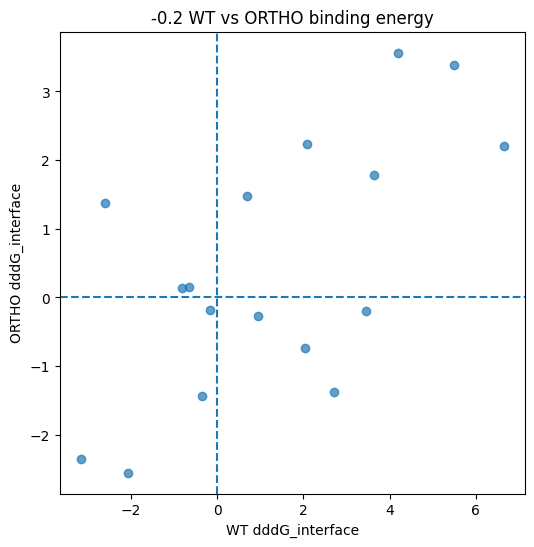

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    pairs["ddG_interface_wt"],
    pairs["ddG_interface_ortho"],
    alpha=0.7
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("WT dddG_interface")
plt.ylabel("ORTHO dddG_interface")
plt.title("-0.2 WT vs ORTHO binding energy")

plt.show()

In [33]:
interesting = pairs[
    (pairs["ddG_interface_wt"] > 1) &
    (pairs["ddG_interface_ortho"] < -1)
]

print(f"Found {len(interesting)} orthogonal candidates:\n")

print(
    interesting[
        ["mut", "mutation_ortho", "mutation_wt",
         "ddG_interface_wt", "ddG_interface_ortho"]
    ].sort_values("ddG_interface_ortho")
    .to_string(index=False)
)

Found 1 orthogonal candidates:

      mut                mutation_ortho                mutation_wt  ddG_interface_wt  ddG_interface_ortho
B57K_A73T 0.2_relaxed_ortho_3_B57K_A73T 0.2_relaxed_wt_1_B57K_A73T            2.7106              -1.3758


In [34]:
import pandas as pd
ortho = pd.read_csv('0.4orthonegweights_avg.csv')
wt = pd.read_csv('0.4wtnegweights_avg.csv')

In [35]:
import re


def extract_rep(s):
    s = str(s)
    m = re.search(r'_rep(\d+)', s)   # works with _rep1 or _rep1.pdb
    return int(m.group(1)) if m else None

def extract_mut(s):
    """
    Extract mutation tokens like A22K, A49L, B57N anywhere in the filename,
    after removing extension and optional replicate suffix.
    """
    s = str(s)
    s = re.sub(r'\.pdb$', '', s)     # drop .pdb if present
    s = re.sub(r'_rep\d+$', '', s)   # drop trailing _repN if present (after .pdb removal)
    muts = re.findall(r'[A-Z]\d+[A-Z]', s)
    return "_".join(muts) if muts else "WT"


# ----------------------------
# Apply extraction
# ----------------------------
ortho["mut"] = ortho["mutation"].apply(extract_mut)
wt["mut"]    = wt["mutation"].apply(extract_mut)

ortho["rep"] = ortho["mutation"].apply(extract_rep)
wt["rep"]    = wt["mutation"].apply(extract_rep)

# ----------------------------
# DEBUG: check extracted keys
# ----------------------------
print("\nORTHO parsed keys (sample):")
print(ortho[["mutation","mut","rep"]].head(10).to_string(index=False))

print("\nWT parsed keys (sample):")
print(wt[["mutation","mut","rep"]].head(10).to_string(index=False))


# ----------------------------
# Merge on mutation set + replicate
# ----------------------------
pairs = ortho.merge(
    wt,
    on=["mut","rep"],
    suffixes=("_ortho","_wt"),
    how="inner"
)

pairs["id"] = range(1, len(pairs)+1)

print(f"\nTotal paired structures: {len(pairs)}")

for _, r in pairs.iterrows():
    print(f'{r["mut"]}')
    print(f'   ORTHO: {r["mutation_ortho"]}')
    print(f'   WT   : {r["mutation_wt"]}')
    print()


ORTHO parsed keys (sample):
                          mutation            mut  rep
     0.4_relaxed_ortho_3_A27K_A73D      A27K_A73D None
     0.4_relaxed_ortho_3_A27K_A73L      A27K_A73L None
     0.4_relaxed_ortho_3_A27K_A73M      A27K_A73M None
     0.4_relaxed_ortho_3_A27K_A73T      A27K_A73T None
     0.4_relaxed_ortho_3_A27K_A73Y      A27K_A73Y None
0.4_relaxed_ortho_3_A27K_B54I_A73T A27K_B54I_A73T None
0.4_relaxed_ortho_3_A27K_B54L_A73K A27K_B54L_A73K None
0.4_relaxed_ortho_3_A27K_B54L_A73L A27K_B54L_A73L None
0.4_relaxed_ortho_3_A27K_B54V_A73T A27K_B54V_A73T None
0.4_relaxed_ortho_3_A27K_B57R_A73I A27K_B57R_A73I None

WT parsed keys (sample):
                       mutation            mut  rep
     0.4_relaxed_wt_1_A27K_A73D      A27K_A73D None
     0.4_relaxed_wt_1_A27K_A73L      A27K_A73L None
     0.4_relaxed_wt_1_A27K_A73M      A27K_A73M None
     0.4_relaxed_wt_1_A27K_A73T      A27K_A73T None
     0.4_relaxed_wt_1_A27K_A73Y      A27K_A73Y None
0.4_relaxed_wt_1_A27K_B54I_A

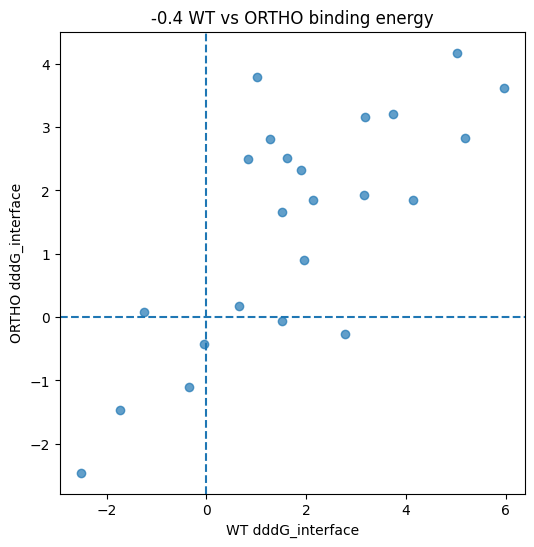

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    pairs["ddG_interface_wt"],
    pairs["ddG_interface_ortho"],
    alpha=0.7
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("WT dddG_interface")
plt.ylabel("ORTHO dddG_interface")
plt.title("-0.4 WT vs ORTHO binding energy")

plt.show()

In [37]:
interesting = pairs[
    (pairs["ddG_interface_wt"] > 1) &
    (pairs["ddG_interface_ortho"] < -1)
]

print(f"Found {len(interesting)} orthogonal candidates:\n")

print(
    interesting[
        ["mut", "mutation_ortho", "mutation_wt",
         "ddG_interface_wt", "ddG_interface_ortho"]
    ].sort_values("ddG_interface_ortho")
    .to_string(index=False)
)

Found 0 orthogonal candidates:

Empty DataFrame
Columns: [mut, mutation_ortho, mutation_wt, ddG_interface_wt, ddG_interface_ortho]
Index: []



ORTHO parsed keys (sample):
                               mutation                 mut  rep
          0.6_relaxed_ortho_3_A27A_A73E           A27A_A73E None
          0.6_relaxed_ortho_3_A27D_A73E           A27D_A73E None
     0.6_relaxed_ortho_3_A27E_A34G_A73T      A27E_A34G_A73T None
0.6_relaxed_ortho_3_A27K_A31N_A34T_A73T A27K_A31N_A34T_A73T None
0.6_relaxed_ortho_3_A27K_A31N_B57R_A73K A27K_A31N_B57R_A73K None
0.6_relaxed_ortho_3_A27K_A34T_B54I_A73L A27K_A34T_B54I_A73L None
          0.6_relaxed_ortho_3_A27K_A73K           A27K_A73K None
          0.6_relaxed_ortho_3_A27K_A73Y           A27K_A73Y None
     0.6_relaxed_ortho_3_A27K_B54F_A73L      A27K_B54F_A73L None
     0.6_relaxed_ortho_3_A27K_B54L_A73E      A27K_B54L_A73E None

WT parsed keys (sample):
                            mutation                 mut  rep
          0.6_relaxed_wt_1_A27A_A73E           A27A_A73E None
          0.6_relaxed_wt_1_A27D_A73E           A27D_A73E None
     0.6_relaxed_wt_1_A27E_A34G_A73T      A2

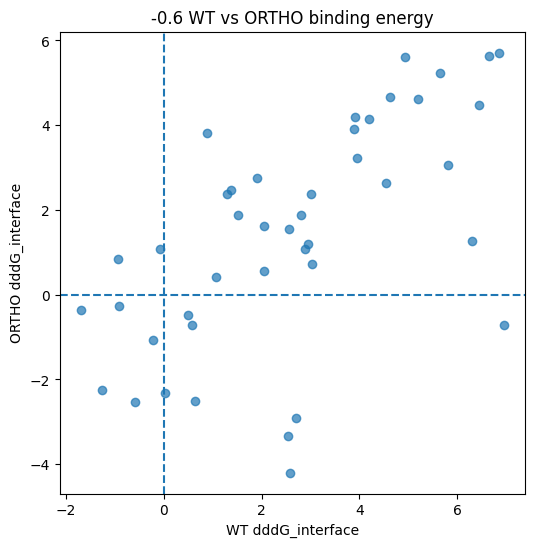

In [38]:
import pandas as pd
ortho = pd.read_csv('0.6orthonegweights_avg.csv')
wt = pd.read_csv('0.6wtnegweights_avg.csv')


import re


def extract_rep(s):
    s = str(s)
    m = re.search(r'_rep(\d+)', s)   # works with _rep1 or _rep1.pdb
    return int(m.group(1)) if m else None

def extract_mut(s):
    """
    Extract mutation tokens like A22K, A49L, B57N anywhere in the filename,
    after removing extension and optional replicate suffix.
    """
    s = str(s)
    s = re.sub(r'\.pdb$', '', s)     # drop .pdb if present
    s = re.sub(r'_rep\d+$', '', s)   # drop trailing _repN if present (after .pdb removal)
    muts = re.findall(r'[A-Z]\d+[A-Z]', s)
    return "_".join(muts) if muts else "WT"


# ----------------------------
# Apply extraction
# ----------------------------
ortho["mut"] = ortho["mutation"].apply(extract_mut)
wt["mut"]    = wt["mutation"].apply(extract_mut)

ortho["rep"] = ortho["mutation"].apply(extract_rep)
wt["rep"]    = wt["mutation"].apply(extract_rep)

# ----------------------------
# DEBUG: check extracted keys
# ----------------------------
print("\nORTHO parsed keys (sample):")
print(ortho[["mutation","mut","rep"]].head(10).to_string(index=False))

print("\nWT parsed keys (sample):")
print(wt[["mutation","mut","rep"]].head(10).to_string(index=False))


# ----------------------------
# Merge on mutation set + replicate
# ----------------------------
pairs = ortho.merge(
    wt,
    on=["mut","rep"],
    suffixes=("_ortho","_wt"),
    how="inner"
)

pairs["id"] = range(1, len(pairs)+1)

print(f"\nTotal paired structures: {len(pairs)}")

for _, r in pairs.iterrows():
    print(f'{r["mut"]}')
    print(f'   ORTHO: {r["mutation_ortho"]}')
    print(f'   WT   : {r["mutation_wt"]}')
    print()


import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    pairs["ddG_interface_wt"],
    pairs["ddG_interface_ortho"],
    alpha=0.7
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("WT dddG_interface")
plt.ylabel("ORTHO dddG_interface")
plt.title("-0.6 WT vs ORTHO binding energy")

plt.show()


In [39]:
interesting = pairs[
    (pairs["ddG_interface_wt"] > 1) &
    (pairs["ddG_interface_ortho"] < -1)
]

print(f"Found {len(interesting)} orthogonal candidates:\n")

print(
    interesting[
        ["mut", "mutation_ortho", "mutation_wt",
         "ddG_interface_wt", "ddG_interface_ortho"]
    ].sort_values("ddG_interface_ortho")
    .to_string(index=False)
)

Found 3 orthogonal candidates:

                mut                          mutation_ortho                          mutation_wt  ddG_interface_wt  ddG_interface_ortho
A34T_B54V_B57R_A73L 0.6_relaxed_ortho_3_A34T_B54V_B57R_A73L 0.6_relaxed_wt_1_A34T_B54V_B57R_A73L            2.5880              -4.2016
A27K_A34T_B54I_A73L 0.6_relaxed_ortho_3_A27K_A34T_B54I_A73L 0.6_relaxed_wt_1_A27K_A34T_B54I_A73L            2.5356              -3.3388
A34T_B54L_B57R_A73T 0.6_relaxed_ortho_3_A34T_B54L_B57R_A73T 0.6_relaxed_wt_1_A34T_B54L_B57R_A73T            2.6970              -2.9246



ORTHO parsed keys (sample):
                                    mutation                      mut  rep
0.8_relaxed_ortho_3_A27A_A31I_B54H_B57V_A73N A27A_A31I_B54H_B57V_A73N None
     0.8_relaxed_ortho_3_A27A_A34H_B54I_A73I      A27A_A34H_B54I_A73I None
          0.8_relaxed_ortho_3_A27A_B54V_A73G           A27A_B54V_A73G None
0.8_relaxed_ortho_3_A27D_A34S_A36D_B54H_A73V A27D_A34S_A36D_B54H_A73V None
          0.8_relaxed_ortho_3_A27D_B57A_A73Q           A27D_B57A_A73Q None
0.8_relaxed_ortho_3_A27E_A31N_A36D_B54I_A73W A27E_A31N_A36D_B54I_A73W None
0.8_relaxed_ortho_3_A27E_A34T_B54L_B57K_A73L A27E_A34T_B54L_B57K_A73L None
          0.8_relaxed_ortho_3_A27H_A31G_B57S           A27H_A31G_B57S None
0.8_relaxed_ortho_3_A27H_A31N_A34D_B54I_A73F A27H_A31N_A34D_B54I_A73F None
0.8_relaxed_ortho_3_A27K_A31H_A36E_B57P_A73L A27K_A31H_A36E_B57P_A73L None

WT parsed keys (sample):
                                 mutation                      mut  rep
0.8_relaxed_wt_1_A27A_A31I_B54H_B57V_A73N A27A_A

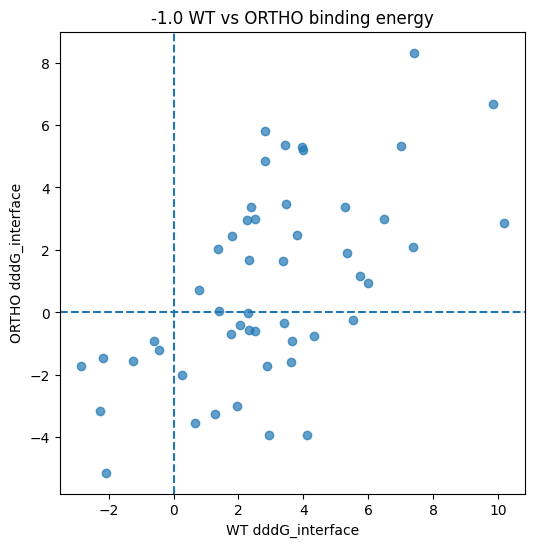

In [40]:
import pandas as pd
ortho = pd.read_csv('0.8orthonegweights_avg.csv')
wt = pd.read_csv('0.8wtnegweights_avg.csv')


import re


def extract_rep(s):
    s = str(s)
    m = re.search(r'_rep(\d+)', s)   # works with _rep1 or _rep1.pdb
    return int(m.group(1)) if m else None

def extract_mut(s):
    """
    Extract mutation tokens like A22K, A49L, B57N anywhere in the filename,
    after removing extension and optional replicate suffix.
    """
    s = str(s)
    s = re.sub(r'\.pdb$', '', s)     # drop .pdb if present
    s = re.sub(r'_rep\d+$', '', s)   # drop trailing _repN if present (after .pdb removal)
    muts = re.findall(r'[A-Z]\d+[A-Z]', s)
    return "_".join(muts) if muts else "WT"


# ----------------------------
# Apply extraction
# ----------------------------
ortho["mut"] = ortho["mutation"].apply(extract_mut)
wt["mut"]    = wt["mutation"].apply(extract_mut)

ortho["rep"] = ortho["mutation"].apply(extract_rep)
wt["rep"]    = wt["mutation"].apply(extract_rep)

# ----------------------------
# DEBUG: check extracted keys
# ----------------------------
print("\nORTHO parsed keys (sample):")
print(ortho[["mutation","mut","rep"]].head(10).to_string(index=False))

print("\nWT parsed keys (sample):")
print(wt[["mutation","mut","rep"]].head(10).to_string(index=False))


# ----------------------------
# Merge on mutation set + replicate
# ----------------------------
pairs = ortho.merge(
    wt,
    on=["mut","rep"],
    suffixes=("_ortho","_wt"),
    how="inner"
)

pairs["id"] = range(1, len(pairs)+1)

print(f"\nTotal paired structures: {len(pairs)}")

for _, r in pairs.iterrows():
    print(f'{r["mut"]}')
    print(f'   ORTHO: {r["mutation_ortho"]}')
    print(f'   WT   : {r["mutation_wt"]}')
    print()


import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    pairs["ddG_interface_wt"],
    pairs["ddG_interface_ortho"],
    alpha=0.7
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("WT dddG_interface")
plt.ylabel("ORTHO dddG_interface")
plt.title("-1.0 WT vs ORTHO binding energy")

plt.show()


In [41]:
interesting = pairs[
    (pairs["ddG_interface_wt"] > 1) &
    (pairs["ddG_interface_ortho"] < -1)
]

print(f"Found {len(interesting)} orthogonal candidates:\n")

print(
    interesting[
        ["mut", "mutation_ortho", "mutation_wt",
         "ddG_interface_wt", "ddG_interface_ortho"]
    ].sort_values("ddG_interface_ortho")
    .to_string(index=False)
)

Found 6 orthogonal candidates:

                               mut                                         mutation_ortho                                         mutation_wt  ddG_interface_wt  ddG_interface_ortho
     A27T_A31N_A34T_B54V_B57H_A73L      0.8_relaxed_ortho_3_A27T_A31N_A34T_B54V_B57H_A73L      0.8_relaxed_wt_1_A27T_A31N_A34T_B54V_B57H_A73L            2.9506              -3.9398
          A27E_A31N_A36D_B54I_A73W           0.8_relaxed_ortho_3_A27E_A31N_A36D_B54I_A73W           0.8_relaxed_wt_1_A27E_A31N_A36D_B54I_A73W            4.1242              -3.9298
     A31N_A34G_A36D_B54L_B57K_A73T      0.8_relaxed_ortho_3_A31N_A34G_A36D_B54L_B57K_A73T      0.8_relaxed_wt_1_A31N_A34G_A36D_B54L_B57K_A73T            1.2824              -3.2658
A27P_A31K_A34D_A36D_B54V_B57M_A73M 0.8_relaxed_ortho_3_A27P_A31K_A34D_A36D_B54V_B57M_A73M 0.8_relaxed_wt_1_A27P_A31K_A34D_A36D_B54V_B57M_A73M            1.9628              -3.0046
          A27T_A36Y_B54L_B57K_A73E           0.8_relaxed_ortho_


ORTHO parsed keys (sample):
                                              mutation                                mut  rep
1.0_relaxed_ortho_3_A27A_A31H_A34P_A36G_B54T_B57T_A73I A27A_A31H_A34P_A36G_B54T_B57T_A73I None
1.0_relaxed_ortho_3_A27A_A31T_A34S_A36Y_B54I_B57G_A73W A27A_A31T_A34S_A36Y_B54I_B57G_A73W None
     1.0_relaxed_ortho_3_A27C_A31A_A34I_B54H_B57T_A73S      A27C_A31A_A34I_B54H_B57T_A73S None
     1.0_relaxed_ortho_3_A27C_A31H_A34K_A36M_B54E_A73D      A27C_A31H_A34K_A36M_B54E_A73D None
     1.0_relaxed_ortho_3_A27C_A31Y_A36A_B54D_B57I_A73A      A27C_A31Y_A36A_B54D_B57I_A73A None
          1.0_relaxed_ortho_3_A27D_A31N_A34H_B54K_B57H           A27D_A31N_A34H_B54K_B57H None
1.0_relaxed_ortho_3_A27D_A31P_A34H_A36A_B54M_B57E_A73K A27D_A31P_A34H_A36A_B54M_B57E_A73K None
1.0_relaxed_ortho_3_A27D_A31T_A34D_A36F_B54R_B57M_A73T A27D_A31T_A34D_A36F_B54R_B57M_A73T None
1.0_relaxed_ortho_3_A27D_A31T_A34R_A36T_B54T_B57L_A73N A27D_A31T_A34R_A36T_B54T_B57L_A73N None
1.0_relaxed_ortho_3_A

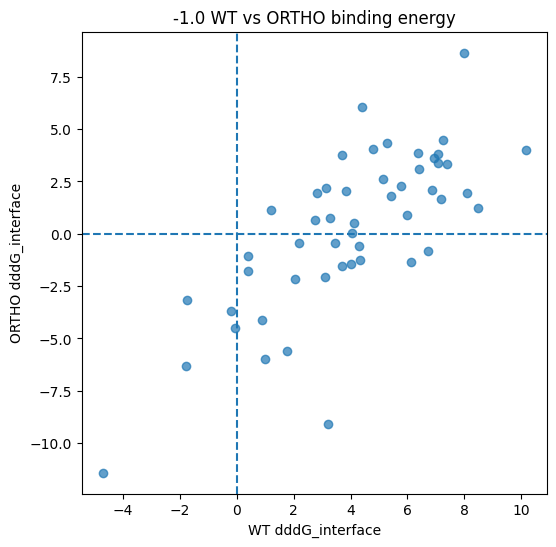

In [42]:
import pandas as pd
ortho = pd.read_csv('1.0orthonegweights_avg.csv')
wt = pd.read_csv('1.0wtnegweights_avg.csv')


import re


def extract_rep(s):
    s = str(s)
    m = re.search(r'_rep(\d+)', s)   # works with _rep1 or _rep1.pdb
    return int(m.group(1)) if m else None

def extract_mut(s):
    """
    Extract mutation tokens like A22K, A49L, B57N anywhere in the filename,
    after removing extension and optional replicate suffix.
    """
    s = str(s)
    s = re.sub(r'\.pdb$', '', s)     # drop .pdb if present
    s = re.sub(r'_rep\d+$', '', s)   # drop trailing _repN if present (after .pdb removal)
    muts = re.findall(r'[A-Z]\d+[A-Z]', s)
    return "_".join(muts) if muts else "WT"


# ----------------------------
# Apply extraction
# ----------------------------
ortho["mut"] = ortho["mutation"].apply(extract_mut)
wt["mut"]    = wt["mutation"].apply(extract_mut)

ortho["rep"] = ortho["mutation"].apply(extract_rep)
wt["rep"]    = wt["mutation"].apply(extract_rep)

# ----------------------------
# DEBUG: check extracted keys
# ----------------------------
print("\nORTHO parsed keys (sample):")
print(ortho[["mutation","mut","rep"]].head(10).to_string(index=False))

print("\nWT parsed keys (sample):")
print(wt[["mutation","mut","rep"]].head(10).to_string(index=False))


# ----------------------------
# Merge on mutation set + replicate
# ----------------------------
pairs = ortho.merge(
    wt,
    on=["mut","rep"],
    suffixes=("_ortho","_wt"),
    how="inner"
)

pairs["id"] = range(1, len(pairs)+1)

print(f"\nTotal paired structures: {len(pairs)}")

for _, r in pairs.iterrows():
    print(f'{r["mut"]}')
    print(f'   ORTHO: {r["mutation_ortho"]}')
    print(f'   WT   : {r["mutation_wt"]}')
    print()


import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    pairs["ddG_interface_wt"],
    pairs["ddG_interface_ortho"],
    alpha=0.7
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("WT dddG_interface")
plt.ylabel("ORTHO dddG_interface")
plt.title("-1.0 WT vs ORTHO binding energy")

plt.show()


In [43]:
interesting = pairs[
    (pairs["ddG_interface_wt"] > 1) &
    (pairs["ddG_interface_ortho"] < -1)
]

print(f"Found {len(interesting)} orthogonal candidates:\n")

print(
    interesting[
        ["mut", "mutation_ortho", "mutation_wt",
         "ddG_interface_wt", "ddG_interface_ortho"]
    ].sort_values("ddG_interface_ortho")
    .to_string(index=False)
)

Found 8 orthogonal candidates:

                               mut                                         mutation_ortho                                         mutation_wt  ddG_interface_wt  ddG_interface_ortho
     A27Y_A31A_A34E_A36I_B54F_B57D      1.0_relaxed_ortho_3_A27Y_A31A_A34E_A36I_B54F_B57D      1.0_relaxed_wt_1_A27Y_A31A_A34E_A36I_B54F_B57D            3.2040              -9.0732
A27E_A31P_A34M_A36R_B54V_B57C_A73K 1.0_relaxed_ortho_3_A27E_A31P_A34M_A36R_B54V_B57C_A73K 1.0_relaxed_wt_1_A27E_A31P_A34M_A36R_B54V_B57C_A73K            1.7776              -5.6300
          A27I_A31T_A34P_B54C_A73I           1.0_relaxed_ortho_3_A27I_A31T_A34P_B54C_A73I           1.0_relaxed_wt_1_A27I_A31T_A34P_B54C_A73I            2.0376              -2.1744
A27F_A31H_A34M_A36L_B54L_B57K_A73N 1.0_relaxed_ortho_3_A27F_A31H_A34M_A36L_B54L_B57K_A73N 1.0_relaxed_wt_1_A27F_A31H_A34M_A36L_B54L_B57K_A73N            3.1058              -2.0712
A27Y_A31S_A34L_A36M_B54E_B57D_A73W 1.0_relaxed_ortho_3_A27Y_A31

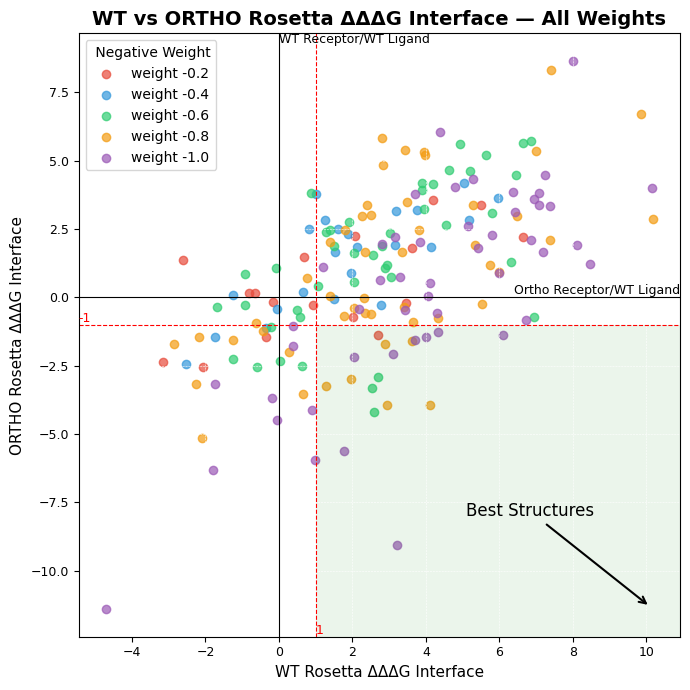

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import re

weights = [-0.2, -0.4, -0.6, -0.8, -1.0]

def extract_rep(s):
    s = str(s)
    m = re.search(r'_rep(\d+)', s)
    return int(m.group(1)) if m else None

def extract_mut(s):
    s = str(s)
    s = re.sub(r'\.pdb$', '', s)
    s = re.sub(r'_rep\d+$', '', s)
    muts = re.findall(r'[A-Z]\d+[A-Z]', s)
    return "_".join(muts) if muts else "WT"

fig, ax = plt.subplots(figsize=(7, 7))

colors = ["#E74C3C", "#3498DB", "#2ECC71", "#F39C12", "#9B59B6"]
# red,      blue,     green,     amber,     purple

for color, w in zip(colors, weights):
    label = str(w)
    ortho = pd.read_csv(f'{abs(w)}orthonegweights_avg.csv')
    wt    = pd.read_csv(f'{abs(w)}wtnegweights_avg.csv')

    for df in [ortho, wt]:
        df["mut"] = df["mutation"].apply(extract_mut)
        df["rep"] = df["mutation"].apply(extract_rep)

    pairs = ortho.merge(wt, on=["mut", "rep"], suffixes=("_ortho", "_wt"), how="inner")

    ax.scatter(
        pairs["ddG_interface_wt"],
        pairs["ddG_interface_ortho"],
        alpha=0.7,
        color=color,
        label=f"weight {w}"
    )
ax.annotate(
    "Best Structures", 
    xy=(0.95, 0.05),           # arrow tip (bottom-right corner)
    xytext=(0.75, 0.20),       # text position
    xycoords="axes fraction",
    textcoords="axes fraction",
    fontsize=12,
    color="black",
    ha="center",
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5)
)
from matplotlib.patches import FancyArrowPatch, Rectangle

xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Shade the bottom-right quadrant beyond your red thresholds
rect = Rectangle(
    (1, ylim[0]),                        # start at x=1, bottom of plot
    xlim[1] - 1,                         # width to right edge
    -1 - ylim[0],                        # height up to y=-1
    linewidth=0, facecolor="green", alpha=0.08
)
ax.add_patch(rect)

ax.grid(True, linestyle="--", linewidth=0.4, color="white", zorder=0)

ax.axhline(0, linestyle="-", color="black", linewidth=0.8)
ax.axvline(0, linestyle="-", color="black", linewidth=0.8)
ax.text(ax.get_xlim()[1], 0, "Ortho Receptor/WT Ligand",
        color="black", va="bottom", ha="right", fontsize=9)

ax.text(0, ax.get_ylim()[1], "WT Receptor/WT Ligand",
        color="black", va="top", ha="left", fontsize=9)
ax.axvline(1, linestyle="--", color="red", linewidth=0.8)
ax.axhline(-1, linestyle="--", color="red", linewidth=0.8)
ax.text(ax.get_xlim()[0], -1, "-1",
        color="red", va="bottom", ha="left", fontsize=9)

ax.text(1, ax.get_ylim()[0], "1",
        color="red", va="bottom", ha="left", fontsize=9)
ax.set_ylabel("ORTHO ddG_interface")
ax.set_xlabel("WT ddG_interface")
ax.set_title("WT vs ORTHO binding energy — all weights")

ax.set_title("WT vs ORTHO Rosetta ΔΔΔG Interface — All Weights", fontsize=14, fontweight="bold")
ax.set_xlabel("WT Rosetta ΔΔΔG Interface", fontsize=11)
ax.set_ylabel("ORTHO Rosetta ΔΔΔG Interface", fontsize=11)
ax.tick_params(labelsize=9)
ax.legend(title=" Negative Weight")
plt.tight_layout()
plt.rcParams["font.family"] = "Arial"
plt.show()

In [3]:
# Collect all pairs across all weights
all_pairs = []
for w in weights:
    ortho = pd.read_csv(f'{abs(w)}orthonegweights_avg.csv')
    wt    = pd.read_csv(f'{abs(w)}wtnegweights_avg.csv')
    for df in [ortho, wt]:
        df["mut"] = df["mutation"].apply(extract_mut)
        df["rep"] = df["mutation"].apply(extract_rep)
    pairs = ortho.merge(wt, on=["mut", "rep"], suffixes=("_ortho", "_wt"), how="inner")
    pairs["weight"] = w
    all_pairs.append(pairs)

combined = pd.concat(all_pairs)

# Bottom-right quadrant: wt > 0, ortho < 0
good = combined[
    (combined["ddG_interface_wt"] > 1) &
    (combined["ddG_interface_ortho"] < -1)
].sort_values("ddG_interface_wt", ascending=False)

print(f"Total structures in bottom-right quadrant: {len(good)}\n")
print(good[["mut", "weight", "ddG_interface_wt", "ddG_interface_ortho"]].to_string(index=False))

Total structures in bottom-right quadrant: 18

                               mut  weight  ddG_interface_wt  ddG_interface_ortho
A27I_A31G_A34D_A36E_B54Q_B57T_A73F    -1.0            6.1106              -1.3726
     A27Y_A31N_A34L_A36Y_B57S_A73E    -1.0            4.3326              -1.2572
          A27E_A31N_A36D_B54I_A73W    -0.8            4.1242              -3.9298
          A27D_A31N_A34H_B54K_B57H    -1.0            4.0038              -1.4740
A27Y_A31S_A34L_A36M_B54E_B57D_A73W    -1.0            3.7082              -1.5524
               A27N_A31K_A34T_A73M    -0.8            3.6338              -1.6074
     A27Y_A31A_A34E_A36I_B54F_B57D    -1.0            3.2040              -9.0732
A27F_A31H_A34M_A36L_B54L_B57K_A73N    -1.0            3.1058              -2.0712
     A27T_A31N_A34T_B54V_B57H_A73L    -0.8            2.9506              -3.9398
          A27T_A36Y_B54L_B57K_A73E    -0.8            2.8782              -1.7120
                         B57K_A73T    -0.2         

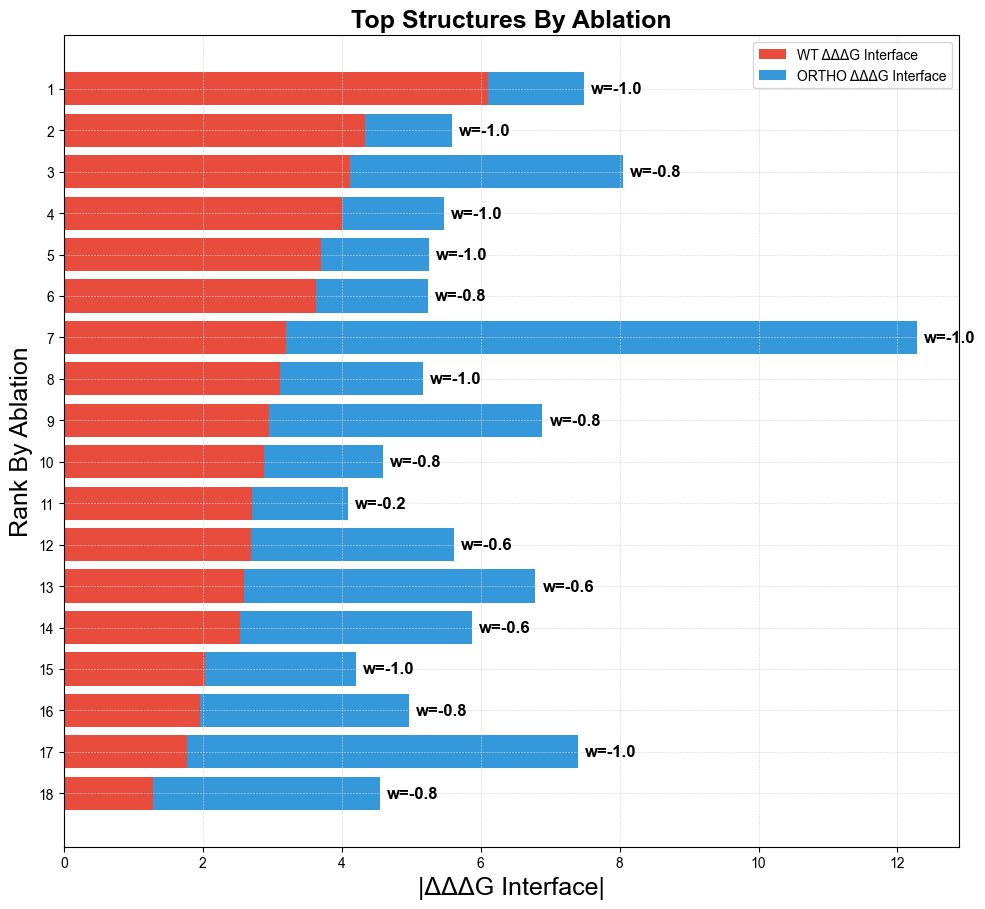

In [4]:
good["total"] = good["ddG_interface_wt"].abs() + good["ddG_interface_ortho"].abs()
good = good.sort_values("ddG_interface_wt", ascending=False).reset_index(drop=True)

ranks = list(range(1, len(good) + 1))

wt_vals    = good["ddG_interface_wt"].abs().values
ortho_vals = good["ddG_interface_ortho"].abs().values
totals     = wt_vals + ortho_vals

fig, ax = plt.subplots(figsize=(10, len(good) * 0.4 + 2))

ax.barh(ranks, wt_vals,    color="#E74C3C", label="WT ΔΔΔG Interface")
ax.barh(ranks, ortho_vals, left=wt_vals,    color="#3498DB", label="ORTHO ΔΔΔG Interface")

# Add weight label at the end of each bar
for rank, total, w in zip(ranks, totals, good["weight"].values):
    ax.text(total + 0.1, rank, f"w={w}", va="center", ha="left", fontsize=12,fontweight="bold", color="black")

ax.set_yticks(ranks)
ax.set_yticklabels(ranks)
ax.invert_yaxis()

ax.set_ylabel("Rank By Ablation", fontsize=18)
ax.set_xlabel("|ΔΔΔG Interface|", fontsize=18)
ax.set_title("Top Structures By Ablation", fontsize=18, fontweight="bold")
ax.legend()
ax.grid(True, linestyle="--", linewidth=0.4, color="lightgray", zorder=0)
plt.rcParams["font.family"] = "Arial"
plt.tight_layout()
plt.show()

In [5]:
cd crystal/

/Users/zyhuggan/Downloads/Debugging PMPNN/crystal


/Users/zyhuggan/miniconda3/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
import pandas as pd
import glob
import os
import re

# =========================
# USER INPUT
# =========================
folder = "."   # <-- CHANGE THIS

# =========================
# HELPERS
# =========================
def extract_weight(filename):
    """
    Extract numeric sweep value from:
    crystal_0.1_ortho_avg.csv
    """
    m = re.search(r'crystal_(\d+\.\d+)', filename)
    return float(m.group(1)) if m else None


def extract_type(filename):
    """
    Determine whether file is WT or ortho
    """
    if "_ortho_" in filename:
        return "ortho"
    elif "_wt_" in filename:
        return "wt"
    return None


# =========================
# LOAD ALL CSV FILES
# =========================
csv_files = glob.glob(os.path.join(folder, "*.csv"))

print(f"Found {len(csv_files)} csv files")

records = []

for f in csv_files:
    fname = os.path.basename(f)

    weight = extract_weight(fname)
    kind = extract_type(fname)

    if weight is None or kind is None:
        print(f"Skipping unrecognized file: {fname}")
        continue

    df = pd.read_csv(f)

    # average numeric columns inside each file
    avg_row = df.mean(numeric_only=True)

    row = avg_row.to_dict()
    row["weight"] = weight
    row["type"] = kind
    row["filename"] = fname

    records.append(row)

combined = pd.DataFrame(records)

# =========================
# SPLIT WT / ORTHO
# =========================
ortho = combined[combined["type"] == "ortho"].copy()
wt = combined[combined["type"] == "wt"].copy()

# =========================
# MERGE BY WEIGHT
# =========================
pairs = ortho.merge(
    wt,
    on="weight",
    suffixes=("_ortho", "_wt"),
    how="inner"
)

pairs = pairs.sort_values("weight").reset_index(drop=True)

print("\nPaired files:")
print(
    pairs[["weight", "filename_ortho", "filename_wt"]]
    .to_string(index=False)
)

# =========================
# SAVE
# =========================
out_csv = os.path.join(folder, "paired_weight_summary.csv")
pairs.to_csv(out_csv, index=False)

print(f"\nSaved paired summary to:\n{out_csv}")

Found 13 csv files
Skipping unrecognized file: paired_weight_summary.csv

Paired files:
 weight            filename_ortho            filename_wt
    0.1 crystal_0.1_ortho_avg.csv crystal_0.1_wt_avg.csv
    0.2 crystal_0.2_ortho_avg.csv crystal_0.2_wt_avg.csv
    0.4 crystal_0.4_ortho_avg.csv crystal_0.4_wt_avg.csv
    0.6 crystal_0.6_ortho_avg.csv crystal_0.6_wt_avg.csv
    0.8 crystal_0.8_ortho_avg.csv crystal_0.8_wt_avg.csv
    1.0 crystal_1.0_ortho_avg.csv crystal_1.0_wt_avg.csv

Saved paired summary to:
./paired_weight_summary.csv


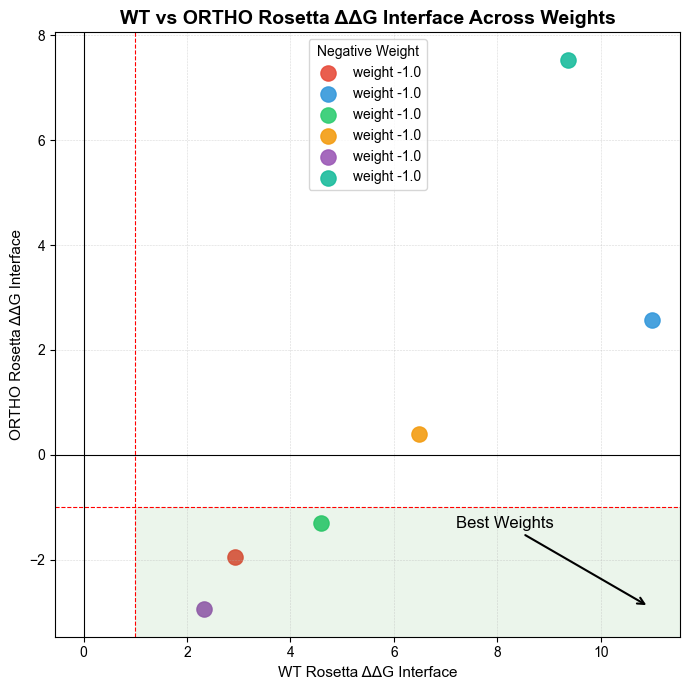

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(7,7))

# nice slide-friendly colors
colors = ["#E74C3C", "#3498DB", "#2ECC71", "#F39C12", "#9B59B6", "#1ABC9C"]

pairs = pairs.sort_values("weight")

for color, (_, row) in zip(colors, pairs.iterrows()):
    ax.scatter(
        row["ddG_interface_wt"],
        row["ddG_interface_ortho"],
        s=120,
        color=color,
        alpha=0.9,
        label=f'weight {row["weight"]}'
    )

# -------------------------
# quadrant guides
# -------------------------
ax.axhline(0, linestyle="-", color="black", linewidth=0.8)
ax.axvline(0, linestyle="-", color="black", linewidth=0.8)

ax.axvline(1, linestyle="--", color="red", linewidth=0.8)
ax.axhline(-1, linestyle="--", color="red", linewidth=0.8)

# -------------------------
# shaded best region
# -------------------------
xlim = ax.get_xlim()
ylim = ax.get_ylim()

rect = Rectangle(
    (1, ylim[0]),
    xlim[1] - 1,
    -1 - ylim[0],
    linewidth=0,
    facecolor="green",
    alpha=0.08
)
ax.add_patch(rect)

# -------------------------
# annotation
# -------------------------
ax.annotate(
    "Best Weights",
    xy=(0.95, 0.05),
    xytext=(0.72, 0.18),
    xycoords="axes fraction",
    textcoords="axes fraction",
    fontsize=12,
    ha="center",
    arrowprops=dict(arrowstyle="->", lw=1.5)
)

# -------------------------
# labels
# -------------------------
ax.set_title(
    "WT vs ORTHO Rosetta ΔΔG Interface Across Weights",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("WT Rosetta ΔΔG Interface", fontsize=11)
ax.set_ylabel("ORTHO Rosetta ΔΔG Interface", fontsize=11)

ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
ax.legend(title="Negative Weight")

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
import glob
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# =====================================
# HELPERS
# =====================================
def extract_weight(filename):
    m = re.search(r'crystal_(\d+(?:\.\d+)?)', filename)
    return float(m.group(1)) if m else None


def extract_mut(s):
    """
    Extract only mutation bundle from row names
    Example:
    0.1_relaxed_ortho_3_A27K_B54V_A73L
    -> A27K_B54V_A73L
    """
    muts = re.findall(r'[A-Z]\d+[A-Z]', str(s))
    return "_".join(muts)


# =====================================
# FIND ALL WEIGHTS
# =====================================
all_csvs = glob.glob("crystal_*csv")
weights = sorted(set(extract_weight(f) for f in all_csvs))

all_pairs = []

# =====================================
# LOOP WEIGHT BY WEIGHT
# =====================================
for w in weights:
    ortho_file = f"crystal_{w}_ortho_avg.csv"
    wt_file    = f"crystal_{w}_wt_avg.csv"

    if ortho_file not in all_csvs or wt_file not in all_csvs:
        print(f"Missing pair for weight {w}")
        continue

    print(f"Pairing weight {w}")

    ortho = pd.read_csv(ortho_file)
    wt = pd.read_csv(wt_file)

    # mutation key inside THIS weight
    ortho["mut"] = ortho["mutation"].apply(extract_mut)
    wt["mut"] = wt["mutation"].apply(extract_mut)

    # pair shared mutation rows
    paired = ortho.merge(
        wt,
        on="mut",
        suffixes=("_ortho", "_wt"),
        how="inner"
    )

    paired["weight"] = -w
    all_pairs.append(paired)

# =====================================
# COMBINE ALL WEIGHTS
# =====================================
pairs = pd.concat(all_pairs, ignore_index=True)

print(f"\nTotal paired rows across all weights: {len(pairs)}")
pairs.head()

Pairing weight 0.1
Pairing weight 0.2
Pairing weight 0.4
Pairing weight 0.6
Pairing weight 0.8
Pairing weight 1.0

Total paired rows across all weights: 194


,mutation_ortho,dG_interface_ortho,ddG_interface_ortho,dG_complex_ortho,ddG_complex_ortho,dG_receptor_ortho,ddG_receptor_ortho,dG_ligand_ortho,ddG_ligand_ortho,mut,mutation_wt,dG_interface_wt,ddG_interface_wt,dG_complex_wt,ddG_complex_wt,dG_receptor_wt,ddG_receptor_wt,dG_ligand_wt,ddG_ligand_wt,weight
0,0.1_relaxed_ortho_3_A27K_B54I_A73L,-85.0678,-1.0232,-1292.9302,-4.5082,-713.0168,1.2452,461.1204,-12.7932,A27K_B54I_A73L,0.1_relaxed_wt_1_A27K_B54I_A73L,-88.9428,0.8116,-1307.1764,-4.8384,-717.4324,0.2840,456.9858,6.3008,-0.1
1,0.1_relaxed_ortho_3_A27K_B54V_A73L,-83.8750,0.1696,-1293.4732,-5.0514,-714.2018,0.0602,443.6286,-30.2854,A27K_B54V_A73L,0.1_relaxed_wt_1_A27K_B54V_A73L,-87.6036,2.1508,-1309.2834,-6.9454,-718.4306,-0.7138,453.5240,2.8386,-0.1
2,0.1_relaxed_ortho_3_A27K_B54V_A73Y,-83.8108,0.2338,-1292.7776,-4.3556,-713.8650,0.3970,435.3172,-38.5968,A27K_B54V_A73Y,0.1_relaxed_wt_1_A27K_B54V_A73Y,-90.2712,-0.5170,-1309.7198,-7.3818,-718.5018,-0.7854,456.8432,6.1582,-0.1
3,0.1_relaxed_ortho_3_A27K_B54V_B57K_A73Y,-85.3114,-1.2666,-1292.9898,-4.5678,-713.8806,0.3814,438.1476,-35.7664,A27K_B54V_B57K_A73Y,0.1_relaxed_wt_1_A27K_B54V_B57K_A73Y,-92.1730,-2.4188,-1309.7956,-7.4576,-718.1874,-0.4704,458.2218,7.5368,-0.1
4,0.1_relaxed_ortho_3_A27K_B54V_B57R_A73L,-83.2932,0.7516,-1292.0488,-3.6268,-713.9734,0.2886,455.3192,-18.5948,A27K_B54V_B57R_A73L,0.1_relaxed_wt_1_A27K_B54V_B57R_A73L,-87.7578,1.9968,-1307.5610,-5.2230,-718.5074,-0.7906,457.7384,7.0534,-0.1


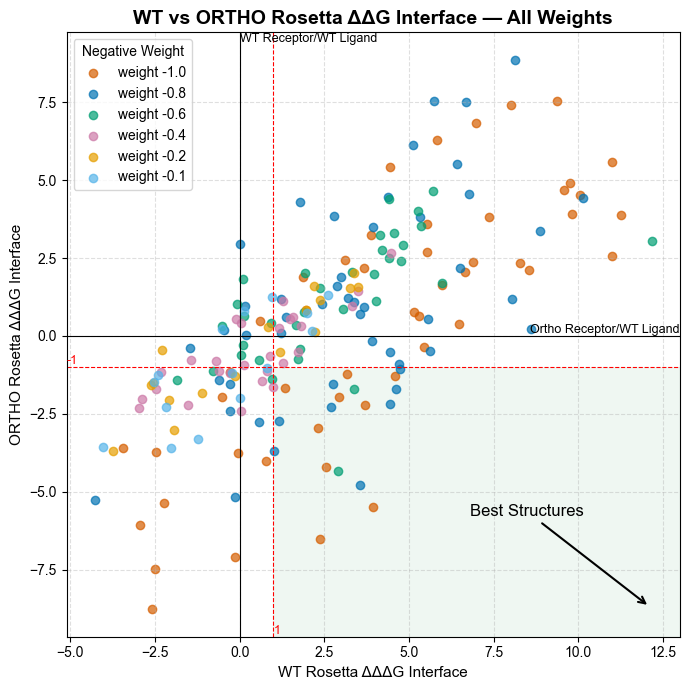

In [21]:
fig, ax = plt.subplots(figsize=(7,7))

weights = sorted(pairs["weight"].unique())

# 6 colors now
colors = [
    "#D55E00",  # burnt orange
    "#0072B2",  # deep blue
    "#009E73",  # teal green
    "#CC79A7",  # magenta
    "#E69F00",  # warm gold
    "#56B4E9"   # sky blue
]

for color, w in zip(colors, weights):
    subset = pairs[pairs["weight"] == w]

    ax.scatter(
        subset["ddG_interface_wt"],
        subset["ddG_interface_ortho"],
        alpha=0.7,
        color=color,
        label=f"weight {w}"
    )
ax.text(ax.get_xlim()[1], 0, "Ortho Receptor/WT Ligand",
        color="black", va="bottom", ha="right", fontsize=9)

ax.text(0, ax.get_ylim()[1], "WT Receptor/WT Ligand",
        color="black", va="top", ha="left", fontsize=9)
ax.text(ax.get_xlim()[0], -1, "-1",
        color="red", va="bottom", ha="left", fontsize=9)

ax.text(1, ax.get_ylim()[0], "1",
        color="red", va="bottom", ha="left", fontsize=9)
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.axvline(1, linestyle="--", color="red", linewidth=0.8)
ax.axhline(-1, linestyle="--", color="red", linewidth=0.8)
# Shade the bottom-right quadrant beyond your red thresholds
xlim = ax.get_xlim()
ylim = ax.get_ylim()

rect = Rectangle(
    (1, ylim[0]),          # x starts at WT threshold
    xlim[1] - 1,           # extend to right edge
    -1 - ylim[0],          # extend up to ortho threshold
    linewidth=0,
    facecolor="#A8D5BA",
    alpha=0.18,
    zorder=0               # keep it behind points
)
ax.annotate(
    "Best Structures", 
    xy=(0.95, 0.05),           # arrow tip (bottom-right corner)
    xytext=(0.75, 0.20),       # text position
    xycoords="axes fraction",
    textcoords="axes fraction",
    fontsize=12,
    color="black",
    ha="center",
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5)
)
ax.add_patch(rect)
ax.set_title("WT vs ORTHO Rosetta ΔΔG Interface — All Weights",
             fontsize=14, fontweight="bold")
ax.set_xlabel("WT Rosetta ΔΔΔG Interface", fontsize=11)
ax.set_ylabel("ORTHO Rosetta ΔΔΔG Interface", fontsize=11)

ax.legend(title="Negative Weight")
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [10]:
# Bottom-right = WT destabilized, ortho stabilized
good = pairs[
    (pairs["ddG_interface_wt"] > 1) &
    (pairs["ddG_interface_ortho"] < -1)
].copy()

good = good.sort_values(
    ["weight", "ddG_interface_wt"],
    ascending=[True, False]
)

print(f"Total structures in bottom-right quadrant: {len(good)}\n")

print(
    good[
        [
            "mut",
            "weight",
            "ddG_interface_wt",
            "ddG_interface_ortho"
        ]
    ].to_string(index=False)
)

Total structures in bottom-right quadrant: 19

                               mut  weight  ddG_interface_wt  ddG_interface_ortho
A27E_A31F_A34E_A36K_B54W_B57Q_A73K    -1.0            4.5984              -1.2988
A27Q_A31S_A34C_A36Y_B54T_B57W_A73Q    -1.0            3.9420              -5.4816
A27L_A31F_A34V_A36E_B54I_B57A_A73T    -1.0            3.7134              -2.2130
A27E_A31R_A34D_A36D_B54F_B57F_A73G    -1.0            3.1706              -1.2288
          A27Y_A31E_A36I_B57E_A73T    -1.0            2.9340              -1.9532
A27K_A31F_A34M_A36K_B54I_B57I_A73I    -1.0            2.5608              -4.1970
A27D_A31A_A34C_A36Y_B54W_B57W_A73K    -1.0            2.3854              -6.5212
     A27E_A31F_A34C_A36A_B57L_A73G    -1.0            2.3218              -2.9422
     A27L_A31L_A34P_A36T_B54L_B57I    -1.0            1.3546              -1.6846
          A27K_A34T_A36S_B54V_A73Q    -0.8            4.7314              -1.0492
     A27K_A31Q_A34M_A36D_B54V_A73W    -0.8         

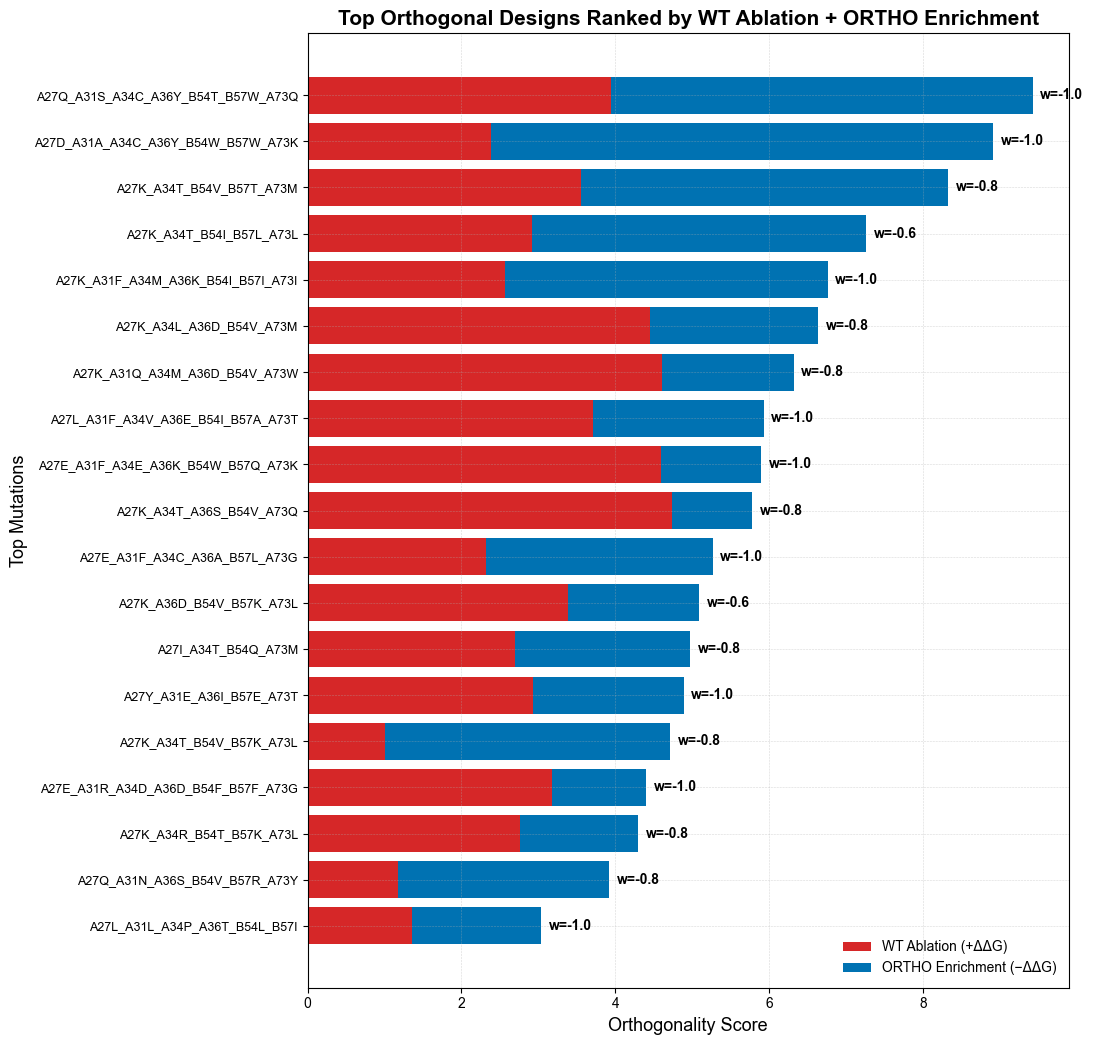

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# ======================================
# RANK BY TOTAL ABLATION + ENRICHMENT
# ======================================
good = good.copy()

# WT loss should be large positive
good["wt_ablation"] = good["ddG_interface_wt"]

# ORTHO gain should be large negative, so flip sign
good["ortho_enrichment"] = -good["ddG_interface_ortho"]

# combined orthogonality score
good["total_score"] = (
    good["wt_ablation"] +
    good["ortho_enrichment"]
)

# rank best designs first
good = good.sort_values(
    "total_score",
    ascending=False
).reset_index(drop=True)

# ======================================
# PLOT
# ======================================
ranks = np.arange(1, len(good) + 1)

wt_color = "#D62728"      # RED = WT loss
ortho_color = "#0072B2"   # BLUE = ORTHO gain

fig, ax = plt.subplots(figsize=(11, len(good)*0.45 + 2))

# WT ablation contribution
ax.barh(
    ranks,
    good["wt_ablation"],
    color=wt_color,
    label="WT Ablation (+ΔΔG)"
)

# ORTHO enrichment contribution
ax.barh(
    ranks,
    good["ortho_enrichment"],
    left=good["wt_ablation"],
    color=ortho_color,
    label="ORTHO Enrichment (−ΔΔG)"
)

# annotate weight and score
for rank, total, w in zip(ranks, good["total_score"], good["weight"]):
    ax.text(
        total + 0.1,
        rank,
        f"w={w}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# mutation labels
ax.set_yticks(ranks)
ax.set_yticklabels(good["mut"], fontsize=9)
ax.invert_yaxis()

# labels
ax.set_xlabel("Orthogonality Score", fontsize=13)
ax.set_ylabel("Top Mutations", fontsize=13)

ax.set_title(
    "Top Orthogonal Designs Ranked by WT Ablation + ORTHO Enrichment",
    fontsize=15,
    fontweight="bold"
)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.show()

In [24]:
print(
    good[
        [
            "mut",
            "weight",
            "wt_ablation",
            "ortho_enrichment",
            "total_score",
            "ddG_interface_wt",
            "ddG_interface_ortho"
        ]
    ].to_string(index=False)
)

                               mut  weight  wt_ablation  ortho_enrichment  total_score  ddG_interface_wt  ddG_interface_ortho
A27Q_A31S_A34C_A36Y_B54T_B57W_A73Q    -1.0       3.9420            5.4816       9.4236            3.9420              -5.4816
A27D_A31A_A34C_A36Y_B54W_B57W_A73K    -1.0       2.3854            6.5212       8.9066            2.3854              -6.5212
          A27K_A34T_B54V_B57T_A73M    -0.8       3.5524            4.7758       8.3282            3.5524              -4.7758
          A27K_A34T_B54I_B57L_A73L    -0.6       2.9196            4.3416       7.2612            2.9196              -4.3416
A27K_A31F_A34M_A36K_B54I_B57I_A73I    -1.0       2.5608            4.1970       6.7578            2.5608              -4.1970
          A27K_A34L_A36D_B54V_A73M    -0.8       4.4506            2.1796       6.6302            4.4506              -2.1796
     A27K_A31Q_A34M_A36D_B54V_A73W    -0.8       4.6040            1.7112       6.3152            4.6040              

In [24]:
cd Enrichment\ Task

/Users/zyhuggan/Downloads/Debugging PMPNN/Enrichment Task


/Users/zyhuggan/miniconda3/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# ============================
# LOAD FILES
# ============================
ortho = pd.read_csv("enrich_ortho_avg.csv")   # change filename
wt = pd.read_csv("enrich_wt_avg.csv")         # change filename


# ============================
# HELPERS
# ============================
def extract_rep(s):
    s = str(s)
    m = re.search(r'_rep(\d+)', s)
    return int(m.group(1)) if m else None


def extract_mut(s):
    """
    Extract mutation bundle from description string.
    Example:
    pos1_relaxed_ortho_3_A27K_B54V_A73L_rep4.pdb
    -> A27K_B54V_A73L
    """
    s = str(s)

    # remove extension
    s = re.sub(r'\.pdb$', '', s)

    # remove replicate
    s = re.sub(r'_rep\d+$', '', s)

    muts = re.findall(r'[A-Z]\d+[A-Z]', s)

    return "_".join(muts) if muts else "WT"


# ============================
# BUILD MERGE KEYS
# ============================
for df in [ortho, wt]:
    df["mut"] = df["mutation"].apply(extract_mut)
    df["rep"] = df["mutation"].apply(extract_rep)

print("ORTHO parsed:")
print(ortho[["mutation", "mut", "rep"]].head())

print("\nWT parsed:")
print(wt[["mutation", "mut", "rep"]].head())


# ============================
# MERGE WT + ORTHO
# ============================
pairs = ortho.merge(
    wt,
    on=["mut", "rep"],
    suffixes=("_ortho", "_wt"),
    how="inner"
)

print(f"\nTotal paired structures: {len(pairs)}")
pairs.head()

ORTHO parsed:
                                   mutation                  mut   rep
0       pos1_relaxed_ortho_3_A27K_B54V_A73L       A27K_B54V_A73L  None
1       pos1_relaxed_ortho_3_A27K_B54V_A73Y       A27K_B54V_A73Y  None
2  pos1_relaxed_ortho_3_A27K_B54V_B57R_A73L  A27K_B54V_B57R_A73L  None
3  pos1_relaxed_ortho_3_A27K_B54V_B57R_A73Y  A27K_B54V_B57R_A73Y  None
4       pos1_relaxed_ortho_3_A27T_B54V_A73L       A27T_B54V_A73L  None

WT parsed:
                                mutation                  mut   rep
0       pos1_relaxed_wt_1_A27K_B54V_A73L       A27K_B54V_A73L  None
1       pos1_relaxed_wt_1_A27K_B54V_A73Y       A27K_B54V_A73Y  None
2  pos1_relaxed_wt_1_A27K_B54V_B57R_A73L  A27K_B54V_B57R_A73L  None
3  pos1_relaxed_wt_1_A27K_B54V_B57R_A73Y  A27K_B54V_B57R_A73Y  None
4       pos1_relaxed_wt_1_A27T_B54V_A73L       A27T_B54V_A73L  None

Total paired structures: 13


,mutation_ortho,dG_interface_ortho,ddG_interface_ortho,dG_complex_ortho,ddG_complex_ortho,dG_receptor_ortho,ddG_receptor_ortho,dG_ligand_ortho,ddG_ligand_ortho,mut,rep,mutation_wt,dG_interface_wt,ddG_interface_wt,dG_complex_wt,ddG_complex_wt,dG_receptor_wt,ddG_receptor_wt,dG_ligand_wt,ddG_ligand_wt
0,pos1_relaxed_ortho_3_A27K_B54V_A73L,-83.7466,0.2976,-1293.6222,-5.2002,-714.0186,0.2430,443.8546,-30.0594,A27K_B54V_A73L,None,pos1_relaxed_wt_1_A27K_B54V_A73L,-87.9088,1.8456,-1308.4336,-6.0956,-717.9400,-0.2232,456.0178,5.3328
1,pos1_relaxed_ortho_3_A27K_B54V_A73Y,-83.7364,0.3080,-1292.6160,-4.1944,-713.8532,0.4088,436.0696,-37.8444,A27K_B54V_A73Y,None,pos1_relaxed_wt_1_A27K_B54V_A73Y,-89.8092,-0.0552,-1309.4056,-7.0676,-718.5848,-0.8682,457.4104,6.7252
2,pos1_relaxed_ortho_3_A27K_B54V_B57R_A73L,-83.1170,0.9270,-1292.1620,-3.7400,-714.0584,0.2036,451.6102,-22.3036,A27K_B54V_B57R_A73L,None,pos1_relaxed_wt_1_A27K_B54V_B57R_A73L,-87.1566,2.5978,-1306.8692,-4.5312,-717.7220,-0.0056,457.0120,6.3270
3,pos1_relaxed_ortho_3_A27K_B54V_B57R_A73Y,-83.3698,0.6752,-1291.7268,-3.3050,-713.8470,0.4148,441.6742,-32.2396,A27K_B54V_B57R_A73Y,None,pos1_relaxed_wt_1_A27K_B54V_B57R_A73Y,-89.6346,0.1196,-1309.2246,-6.8866,-718.7058,-0.9890,453.9452,3.2602
4,pos1_relaxed_ortho_3_A27T_B54V_A73L,-82.6398,1.4044,-1291.5780,-3.1562,-714.1608,0.1012,447.5788,-26.3352,A27T_B54V_A73L,None,pos1_relaxed_wt_1_A27T_B54V_A73L,-86.4110,3.3432,-1307.2526,-4.9146,-717.3660,0.3508,453.3946,2.7096


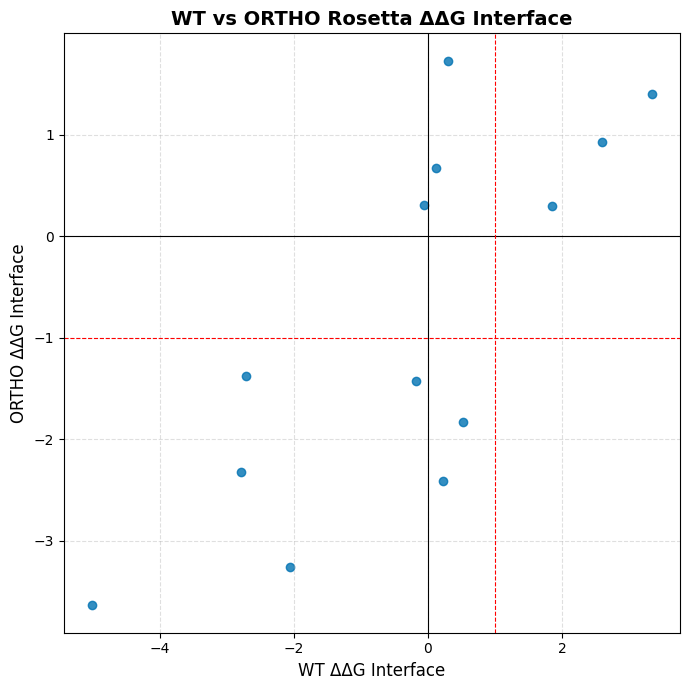

In [28]:
fig, ax = plt.subplots(figsize=(7,7))

ax.scatter(
    pairs["ddG_interface_wt"],
    pairs["ddG_interface_ortho"],
    alpha=0.8,
    color="#0072B2"
)

# guides
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)

# selectivity threshold
ax.axvline(1, linestyle="--", color="red", linewidth=0.8)
ax.axhline(-1, linestyle="--", color="red", linewidth=0.8)

ax.set_xlabel("WT ΔΔG Interface", fontsize=12)
ax.set_ylabel("ORTHO ΔΔG Interface", fontsize=12)

ax.set_title(
    "WT vs ORTHO Rosetta ΔΔG Interface",
    fontsize=14,
    fontweight="bold"
)

ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()